# RAVDESS feature extractor

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def compute_mfdr_singing(f0, conf, step_size_ms=10,
                         low_band=(0.5, 3), vib_band=(4, 8), high_band=(8, 20)):
    """
    Calculates modulation frequency domain ratios for the singing pitch contour.
    Bands:
    - 0.5–3 Hz: slow expressive modulations / phrasing
    - 4–8 Hz: vibrato region
    - 8–20 Hz: micro-modulations / stress / noise
    """
    if len(f0) < 20:
        return {k: np.nan for k in [
            "MFDR_slow", "MFDR_vibrato", "MFDR_high",
            "MFDR_slow2vibrato", "MFDR_vibrato2high"
        ]}

    # Convert to semitones for a constant scale
    st = 12 * np.log2(f0 / 55.0)
    st = st - np.mean(st)

    fs_feat = 1000.0 / step_size_ms  # frame rate
    spec = np.fft.rfft(st)
    freqs = np.fft.rfftfreq(len(st), d=1/fs_feat)
    mag2 = np.abs(spec)**2

    def band_energy(lo, hi):
        mask = (freqs >= lo) & (freqs < hi)
        return np.sum(mag2[mask])

    e_total = band_energy(0.5, 20)
    e_slow = band_energy(*low_band)
    e_vib  = band_energy(*vib_band)
    e_high = band_energy(*high_band)

    return {
        "MFDR_slow": e_slow / e_total,
        "MFDR_vibrato": e_vib / e_total,
        "MFDR_high": e_high / e_total,
        "MFDR_slow2vibrato": (e_slow + 1e-12) / (e_vib + 1e-12),
        "MFDR_vibrato2high": (e_vib + 1e-12) / (e_high + 1e-12)
    }

In [ ]:
df_features.to_csv('/content/drive/MyDrive/df_ravdesscheck.csv', index=False)

# extra!

In [ ]:
!pip install crepe

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 102.3 MB/s eta 0:00:00
  Created wheel for crepe: filename=crepe-0.0.16-py3-none-any.whl size=134848677 sha256=5961ad58ce569b989040d7fb2d801b7a7b8136c64d37a261ec3466b84742e27b
  Stored in directory: /root/.cache/pip/wheels/36/fb/4f/4357617f155cf882b996fb4ee50a2863343262bfa203cb32c5
Successfully built crepe


In [ ]:
!pip install opensmile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 22.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import librosa
import crepe
import os

def parse_ravdess_filename(filename):
    # ... [Ο κώδικάς σου παραμένει ίδιος] ...
    base = os.path.basename(filename)
    base = os.path.splitext(base)[0]
    parts = base.split('-')
    metadata = {
        'modality': int(parts[0]),
        'vocal_channel': int(parts[1]),
        'emotion': int(parts[2]),
        'intensity': int(parts[3]),
        'statement': int(parts[4]),
        'repetition': int(parts[5]),
        'actor_id': int(parts[6]),
        'gender': 'male' if int(parts[6]) % 2 == 1 else 'female'
    }
    return metadata

def extract_extra_features(y, sr):

    # ---------- Spectral Flatness ----------
    flatness = librosa.feature.spectral_flatness(y=y)[0]
    spectral_flatness_mean = np.mean(flatness)
    spectral_flatness_std = np.std(flatness)

    # ---------- Spectral Centroid ----------
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    spectral_centroid_mean = np.mean(centroid)
    spectral_centroid_std = np.std(centroid)

    # ---------- Zero Crossing Rate (ZCR) ----------
    zcr = librosa.feature.zero_crossing_rate(y=y)[0]
    zcr_mean = np.mean(zcr)
    zcr_std = np.std(zcr)

    # ---------- Loudness (RMS) & Energy ----------
    rms = librosa.feature.rms(y=y)[0]
    st_loud_var = np.mean(np.abs(np.diff(rms)))
    lt_loud_var = np.max(rms) - np.min(rms)
    delta_energy = np.diff(rms)

    try:
        # CREPE Pitch Tracking
        time, f0, conf, _ = crepe.predict(y, sr, model_capacity="medium", step_size=10, verbose=False)

        f0_flat = f0.flatten()
        conf_flat = conf.flatten()

        # Κρατάμε τα valid frames για τα συνολικά features (DETT, variability κλπ)
        mask = conf_flat > 0.7
        f0_voiced = f0_flat[mask]

        if len(f0_voiced) > 10:
            st = 12 * np.log2(f0_voiced / 440.0)

            # 1. Melodic & Variability Features (Συνολικά για το αρχείο)
            pitch_variability = np.std(st)
            melodic_deviation = np.mean(np.abs(st - np.mean(st)))

            # 2. Absolute DETT
            abs_dett_array = np.abs(st - np.round(st))
            dett_mean = np.mean(abs_dett_array)
            dett_sd = np.std(abs_dett_array)

            # 3. Signed DETT
            signed_dett_array = st - np.round(st)
            pitch_bias = np.mean(signed_dett_array)

            # 4. Coefficient of Variation
            dett_cv = dett_sd / dett_mean if dett_mean > 0 else 0

            # 5. Delta Pitch
            delta_pitch = np.diff(st)
            delta_pitch_mean = np.mean(delta_pitch)
            delta_pitch_std = np.std(delta_pitch)

            # Segmentation Logic for MFDR
            segments = []
            current_segment = []

            for val, c in zip(f0_flat, conf_flat):
                if c > 0.7:
                    current_segment.append(val)
                else:
                    if len(current_segment) >= 20: # Τουλάχιστον 200ms
                        segments.append(np.array(current_segment))
                    current_segment = []

            if len(current_segment) >= 20:
                segments.append(np.array(current_segment))

            # Υπολογισμός MFDR ανά segment και μέσος όρος
            mfdr_list = []
            for seg in segments:
                res = compute_mfdr_singing(seg, conf=None, step_size_ms=10)
                if not np.isnan(res["MFDR_slow"]):
                    mfdr_list.append(res)

            if mfdr_list:
                mfdr_features = {}
                for key in mfdr_list[0].keys():
                    mfdr_features[key] = np.mean([r[key] for r in mfdr_list])
            else:
                mfdr_features = {k: np.nan for k in ["MFDR_slow", "MFDR_vibrato", "MFDR_high", "MFDR_slow2vibrato", "MFDR_vibrato2high"]}

        else:
            melodic_deviation = pitch_variability = dett_mean = dett_sd = pitch_bias = dett_cv = delta_pitch_mean = delta_pitch_std = np.nan
            mfdr_features = {k: np.nan for k in ["MFDR_slow", "MFDR_vibrato", "MFDR_high", "MFDR_slow2vibrato", "MFDR_vibrato2high"]}

    except Exception as e:
        print(f"CREPE error: {e}")
        melodic_deviation = pitch_variability = dett_mean = dett_sd = pitch_bias = delta_pitch_mean = delta_pitch_std = dett_cv = np.nan
        mfdr_features = {k: np.nan for k in ["MFDR_slow", "MFDR_vibrato", "MFDR_high", "MFDR_slow2vibrato", "MFDR_vibrato2high"]}

    return {
        "melodic_deviation": melodic_deviation,
        "pitch_variability": pitch_variability,
        "dett_mean": dett_mean,
        "dett_std": dett_sd,
        "dett_cv": dett_cv,
        "pitch_bias": pitch_bias,
        "delta_pitch_mean": delta_pitch_mean,
        "delta_pitch_std": delta_pitch_std,
        "spectral_flatness_mean": spectral_flatness_mean,
        "spectral_flatness_std": spectral_flatness_std,
        "spectral_centroid_mean": spectral_centroid_mean,
        "spectral_centroid_std": spectral_centroid_std,
        "st_loudness_variability": st_loud_var,
        "lt_loudness_variability": lt_loud_var,
        "zcr_mean": zcr_mean,
        "zcr_std": zcr_std,
        "delta_energy_mean": np.mean(delta_energy),
        "delta_energy_std": np.std(delta_energy),
        **mfdr_features
    }

In [ ]:
from tqdm import tqdm
import glob
import pandas as pd
import opensmile, crepe

# recursively search directories
drive_path = "/content/drive/MyDrive/RAVDESS/**/*.wav"

smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.Functionals
)

all_features = []
target_sr = 22050

for wave_file in tqdm(glob.glob(drive_path, recursive=True), desc="Processing files"):
    file_name_only = os.path.basename(wave_file)

    try:
        # Φορτώνουμε μία φορά με το σωστό SR
        y, sr = librosa.load(wave_file, sr=target_sr)
        metadata = parse_ravdess_filename(file_name_only)

        # --- OpenSMILE ---
        # Το process_signal θέλει το σήμα και το SR
        features = smile.process_signal(y, sr)
        opensmile_features = features.iloc[0].to_dict()

        # --- Extra Features (δίνουμε το ήδη καθαρό σήμα) ---
        extra_features = extract_extra_features(y, sr)

        # Combine data
        combined_features = {**metadata, **opensmile_features, **extra_features}
        combined_features["filename"] = file_name_only
        combined_features["full_path"] = wave_file

        all_features.append(combined_features)

    except Exception as e:
        print(f"Error processing {wave_file}: {e}")

df_features = pd.DataFrame(all_features)

Processing files: 100%|██████████| 1012/1012 [26:16<00:00,  1.56s/it]


In [ ]:
df_features.to_csv('/content/drive/MyDrive/df_ravdessv2_check1.csv', index=False)

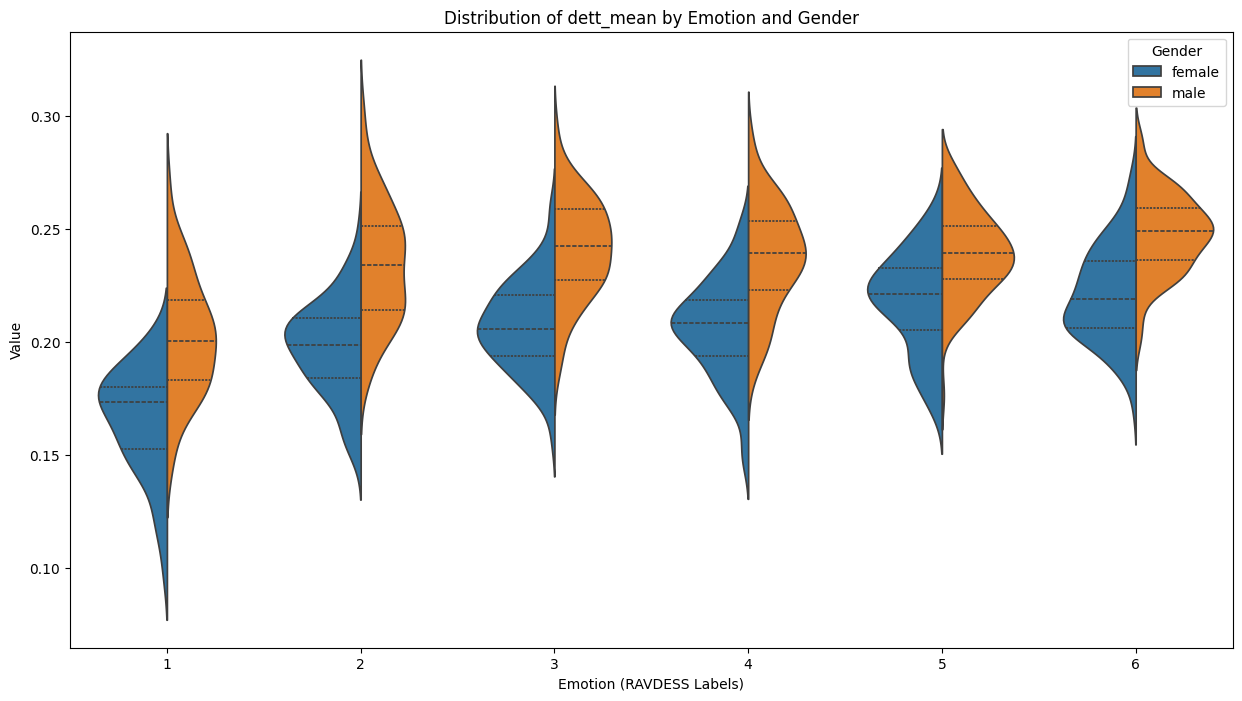

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Επιλέγουμε ένα feature, π.χ. το dett_mean
feature_to_check = 'dett_mean'

plt.figure(figsize=(15, 8))
sns.violinplot(x='emotion', y=feature_to_check, hue='gender', data=df_features, split=True, inner="quart")

plt.title(f'Distribution of {feature_to_check} by Emotion and Gender')
plt.xlabel('Emotion (RAVDESS Labels)')
plt.ylabel('Value')
plt.legend(title='Gender')
plt.show()

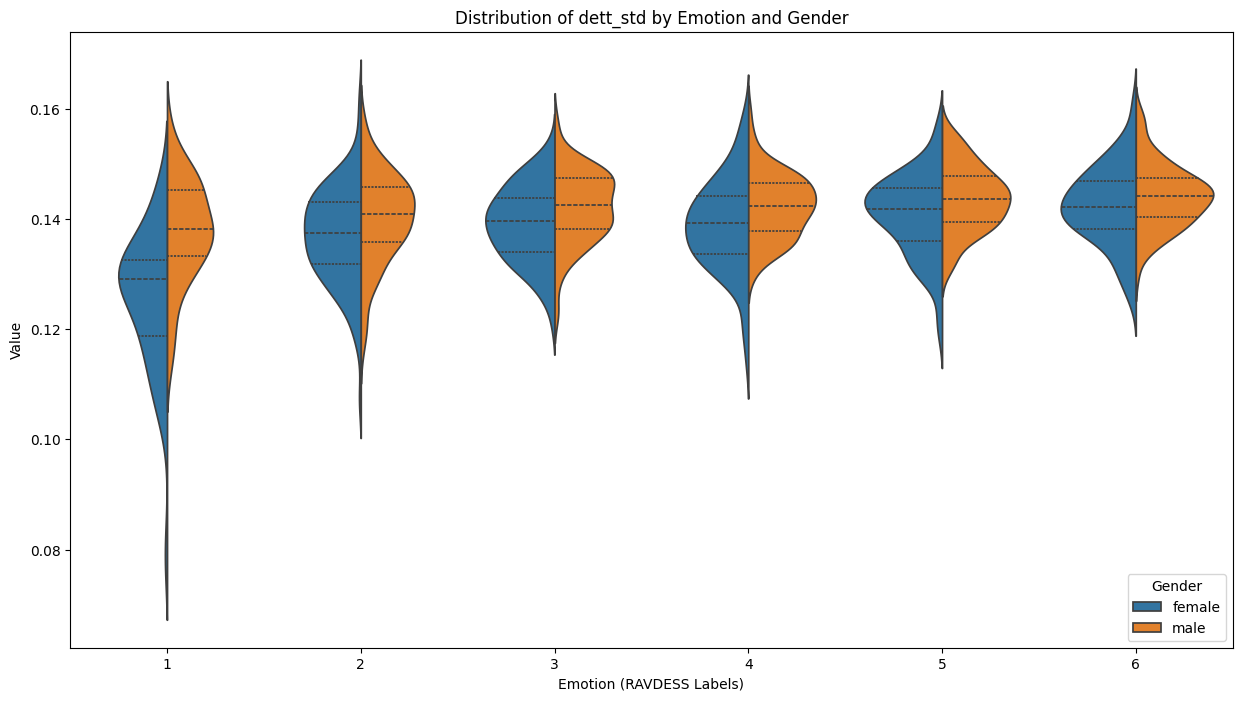

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Επιλέγουμε ένα feature, π.χ. το dett_mean
feature_to_check = 'dett_std'

plt.figure(figsize=(15, 8))
sns.violinplot(x='emotion', y=feature_to_check, hue='gender', data=df_features, split=True, inner="quart")

plt.title(f'Distribution of {feature_to_check} by Emotion and Gender')
plt.xlabel('Emotion (RAVDESS Labels)')
plt.ylabel('Value')
plt.legend(title='Gender')
plt.show()

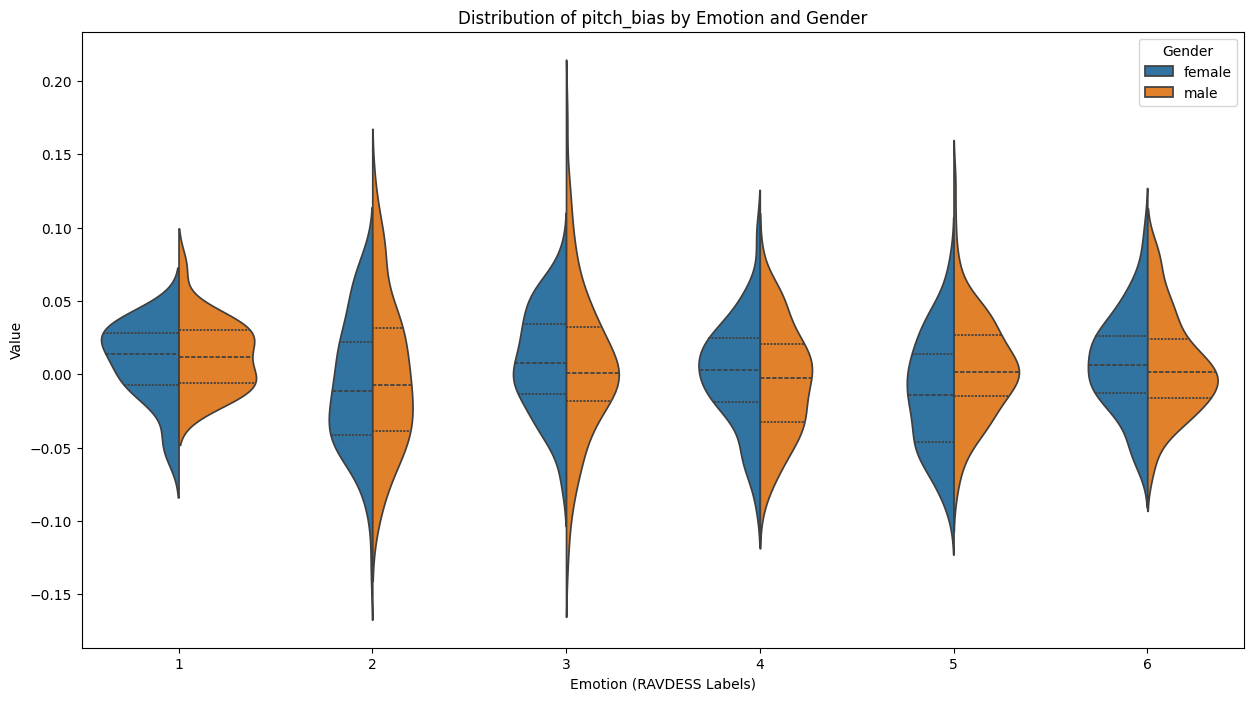

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Επιλέγουμε ένα feature, π.χ. το dett_mean
feature_to_check = 'pitch_bias'

plt.figure(figsize=(15, 8))
sns.violinplot(x='emotion', y=feature_to_check, hue='gender', data=df_features, split=True, inner="quart")

plt.title(f'Distribution of {feature_to_check} by Emotion and Gender')
plt.xlabel('Emotion (RAVDESS Labels)')
plt.ylabel('Value')
plt.legend(title='Gender')
plt.show()

In [ ]:
from scipy.stats import f_oneway

# Έλεγχος για το dett_sd ανά συναίσθημα
emotions = df_features['emotion'].unique()
feature = 'MFDR_vibrato'

groups = [df_features[df_features['emotion'] == e][feature].dropna() for e in emotions]
f_stat, p_val = f_oneway(*groups)

print(f"Feature: {feature}")
print(f"F-statistic: {f_stat:.2f}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print("Στατιστικά σημαντικό! Το feature όντως ξεχωρίζει τα συναισθήματα.")

Feature: MFDR_vibrato
F-statistic: 9.82
p-value: 3.5765e-09
Στατιστικά σημαντικό! Το feature όντως ξεχωρίζει τα συναισθήματα.


In [ ]:
from scipy.stats import f_oneway

# Έλεγχος για το dett_sd ανά συναίσθημα
emotions = df_features['emotion'].unique()
feature = 'dett_mean'

groups = [df_features[df_features['emotion'] == e][feature].dropna() for e in emotions]
f_stat, p_val = f_oneway(*groups)

print(f"Feature: {feature}")
print(f"F-statistic: {f_stat:.2f}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print("Στατιστικά σημαντικό! Το feature όντως ξεχωρίζει τα συναισθήματα.")

Feature: dett_mean
F-statistic: 49.48
p-value: 6.9799e-46
Στατιστικά σημαντικό! Το feature όντως ξεχωρίζει τα συναισθήματα.


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 171ms/step


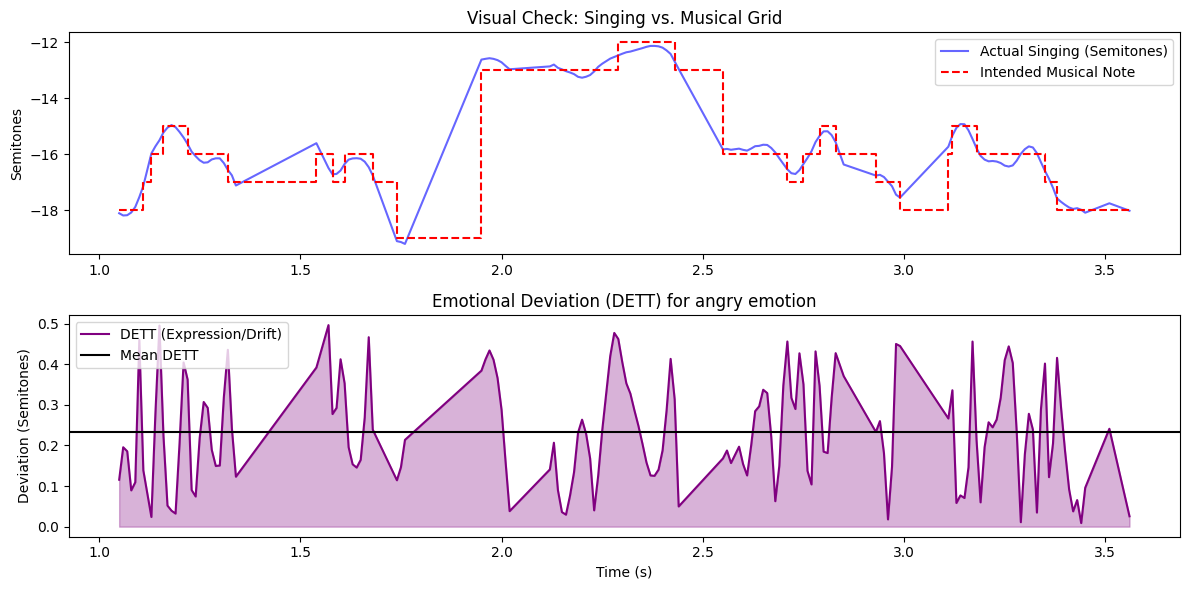

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import crepe
import librosa

# 1. Load a clip and run your extraction
y, sr = librosa.load("/content/03-02-05-01-02-01-01.wav")
time, f0, conf, _ = crepe.predict(y, sr, model_capacity="tiny", step_size=10)

# Filter by confidence
mask = conf > 0.7
f0_clean = f0[mask]
time_clean = time[mask]

# 2. Convert to Semitones
st = 12 * np.log2(f0_clean / 440.0)
target_notes = np.round(st)  # The "Perfect" musical notes
dett_per_frame = np.abs(st - target_notes) # The "Error" or "Expression"

# 3. Plot the results
plt.figure(figsize=(12, 6))

# Top Plot: Pitch vs Target
plt.subplot(2, 1, 1)
plt.plot(time_clean, st, label='Actual Singing (Semitones)', color='blue', alpha=0.6)
plt.step(time_clean, target_notes, label='Intended Musical Note', color='red', where='post', linestyle='--')
plt.title('Visual Check: Singing vs. Musical Grid')
plt.ylabel('Semitones')
plt.legend()

# Bottom Plot: The DETT feature
plt.subplot(2, 1, 2)
plt.fill_between(time_clean, dett_per_frame, color='purple', alpha=0.3)
plt.plot(time_clean, dett_per_frame, color='purple', label='DETT (Expression/Drift)')
plt.axhline(y=np.mean(dett_per_frame), color='black', linestyle='-', label='Mean DETT')
plt.title('Emotional Deviation (DETT) for angry emotion')
plt.ylabel('Deviation (Semitones)')
plt.xlabel('Time (s)')
plt.legend()

plt.tight_layout()
plt.savefig("feature_verification.png")

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step


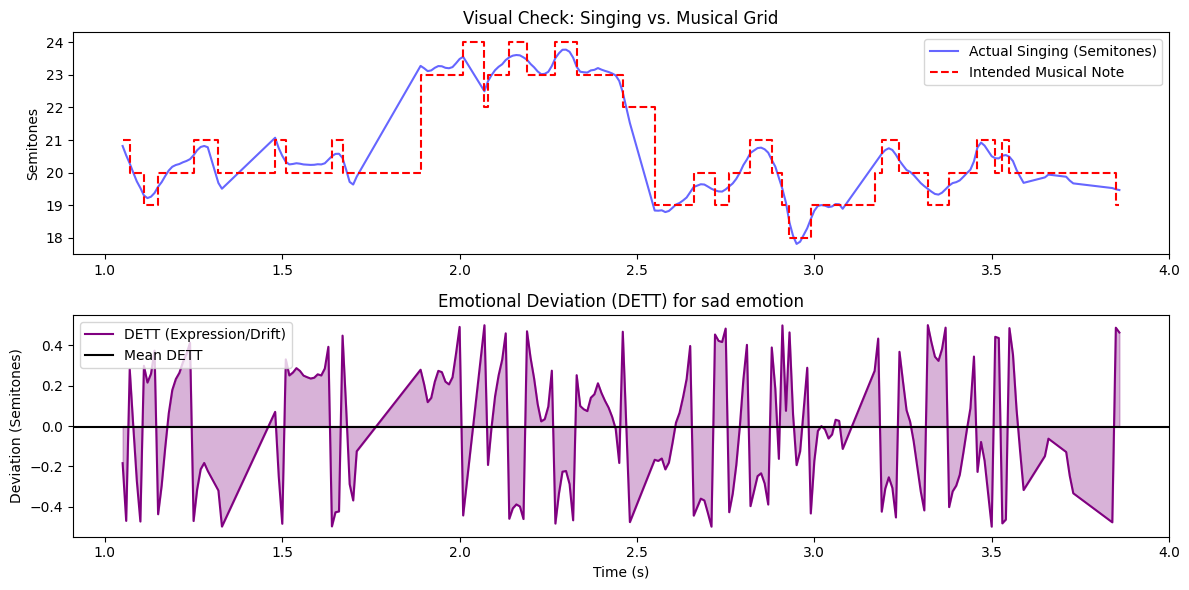

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import crepe
import librosa

# 1. Load a clip and run your extraction
y, sr = librosa.load("/content/03-02-04-02-02-02-01.wav")
time, f0, conf, _ = crepe.predict(y, sr, model_capacity="tiny", step_size=10)

# Filter by confidence
mask = conf > 0.7
f0_clean = f0[mask]
time_clean = time[mask]

# 2. Convert to Semitones
st = 12 * np.log2(f0_clean / 55.0)
target_notes = np.round(st)  # The "Perfect" musical notes
dett_per_frame = (st - target_notes) # The "Error" or "Expression"

# 3. Plot the results
plt.figure(figsize=(12, 6))

# Top Plot: Pitch vs Target
plt.subplot(2, 1, 1)
plt.plot(time_clean, st, label='Actual Singing (Semitones)', color='blue', alpha=0.6)
plt.step(time_clean, target_notes, label='Intended Musical Note', color='red', where='post', linestyle='--')
plt.title('Visual Check: Singing vs. Musical Grid')
plt.ylabel('Semitones')
plt.legend()

# Bottom Plot: The DETT feature
plt.subplot(2, 1, 2)
plt.fill_between(time_clean, dett_per_frame, color='purple', alpha=0.3)
plt.plot(time_clean, dett_per_frame, color='purple', label='DETT (Expression/Drift)')
plt.axhline(y=np.mean(dett_per_frame), color='black', linestyle='-', label='Mean DETT')
plt.title('Emotional Deviation (DETT) for sad emotion')
plt.ylabel('Deviation (Semitones)')
plt.xlabel('Time (s)')
plt.legend()

plt.tight_layout()
plt.savefig("feature_verification.png")

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 157ms/step


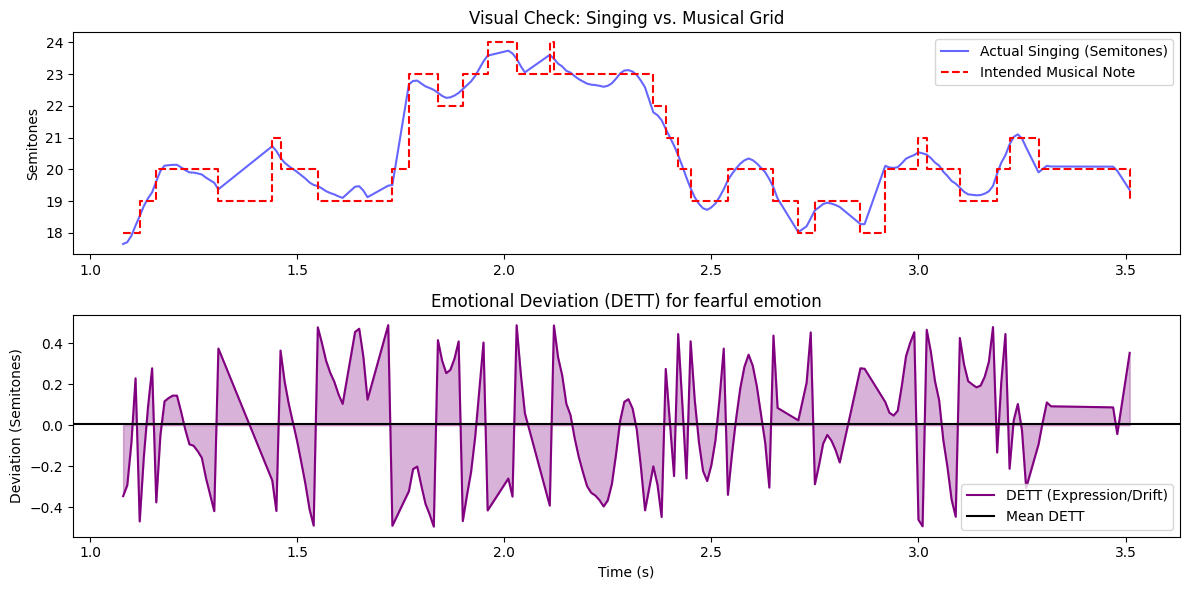

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import crepe
import librosa

# 1. Load a clip and run your extraction
y, sr = librosa.load("/content/03-02-06-01-01-02-01.wav")
time, f0, conf, _ = crepe.predict(y, sr, model_capacity="tiny", step_size=10)

# Filter by confidence
mask = conf > 0.7
f0_clean = f0[mask]
time_clean = time[mask]

# 2. Convert to Semitones
st = 12 * np.log2(f0_clean / 55.0)
target_notes = np.round(st)  # The "Perfect" musical notes
dett_per_frame = (st - target_notes) # The "Error" or "Expression"

# 3. Plot the results
plt.figure(figsize=(12, 6))

# Top Plot: Pitch vs Target
plt.subplot(2, 1, 1)
plt.plot(time_clean, st, label='Actual Singing (Semitones)', color='blue', alpha=0.6)
plt.step(time_clean, target_notes, label='Intended Musical Note', color='red', where='post', linestyle='--')
plt.title('Visual Check: Singing vs. Musical Grid')
plt.ylabel('Semitones')
plt.legend()

# Bottom Plot: The DETT feature
plt.subplot(2, 1, 2)
plt.fill_between(time_clean, dett_per_frame, color='purple', alpha=0.3)
plt.plot(time_clean, dett_per_frame, color='purple', label='DETT (Expression/Drift)')
plt.axhline(y=np.mean(dett_per_frame), color='black', linestyle='-', label='Mean DETT')
plt.title('Emotional Deviation (DETT) for fearful emotion')
plt.ylabel('Deviation (Semitones)')
plt.xlabel('Time (s)')
plt.legend()

plt.tight_layout()
plt.savefig("feature_verification.png")

# cnn

In [ ]:
import librosa
import numpy as np
from tqdm import tqdm

target_sr = 22050
n_mels = 160
hop_length = 256
n_fft = 2048
target_frames = 128
target_samples = target_frames * hop_length

all_mel_chunks = []
all_pitch_chunks = []
chunk_metadata = []

wav_paths = df_features['full_path'].values

for path in tqdm(wav_paths):
    try:
        y, _ = librosa.load(path, sr=target_sr)
    except Exception as e:
        print(f"Error loading {path}: {e}")
        continue

    total_samples = len(y)

    for start_sample in range(0, total_samples, target_samples):
        end_sample = start_sample + target_samples
        chunk_audio = y[start_sample:end_sample]

        # Padding if the chunk is short
        if len(chunk_audio) < target_samples:
            if len(chunk_audio) / target_samples < 0.3: continue # if too short we ignore it
            chunk_audio = np.pad(chunk_audio, (0, target_samples - len(chunk_audio)), mode='constant')

        # 1. Mel-Spectrogram
        S = librosa.feature.melspectrogram(y=chunk_audio, sr=target_sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
        S_dB = librosa.power_to_db(S, ref=np.max)

        # Resize/Fix frames to 128
        if S_dB.shape[1] > target_frames: S_dB = S_dB[:, :target_frames]
        elif S_dB.shape[1] < target_frames: S_dB = np.pad(S_dB, ((0, 0), (0, target_frames - S_dB.shape[1])))

        S_norm = np.clip((S_dB + 80) / 80, 0, 1)

        # Pitch Contour (YIN)
        f0 = librosa.yin(y=chunk_audio, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'),
                         sr=target_sr, hop_length=hop_length)

        f0_norm = np.clip(f0 / librosa.note_to_hz('C7'), 0, 1)

        if len(f0_norm) > target_frames: f0_norm = f0_norm[:target_frames]
        elif len(f0_norm) < target_frames: f0_norm = np.pad(f0_norm, (0, target_frames - len(f0_norm)))

        all_mel_chunks.append(S_norm)
        all_pitch_chunks.append(f0_norm)
        chunk_metadata.append(path)


X_mel_new = np.array(all_mel_chunks)[..., np.newaxis]
X_pitch_new = np.array(all_pitch_chunks)[..., np.newaxis]

print(f"\ready {len(X_mel_new)} chunks")

100%|██████████| 1012/1012 [01:31<00:00, 11.09it/s]


eady 3281 chunks


In [ ]:
import tensorflow as tf
# Load custom cnn model
model = tf.keras.models.load_model("model_pitch_leaky (1).h5")
predictions = model.predict([X_mel_new, X_pitch_new])

tech_cols = ['mix', 'falsetto', 'breathy', 'pharyngeal', 'glissando', 'vibrato']

df_tech_features = pd.DataFrame(predictions, columns=tech_cols)
df_tech_features['full_path'] = chunk_metadata


103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step


In [ ]:
import pandas as pd
from scipy.stats import entropy
import numpy as np

tech_cols = ['vibrato', 'mix', 'falsetto', 'breathy', 'pharyngeal', 'glissando']
features_list = []

for wav, group_raw in df_tech_features.groupby('full_path'):
    group = group_raw.copy()
    features = {'full_path': wav}
    # The Mean indicates the intensity of the technique in the file
    for tech in tech_cols:
        m = group[tech].mean()
        mx = group[tech].max()
        s = group[tech].std()

        features[f'{tech}_mean'] = m
        features[f'{tech}_std'] = s
        features[f'{tech}_max'] = mx
        features[f'{tech}_peak_factor'] = mx / (m + 1e-7)

    # Since the predictions are floats (0.0 - 1.0), we define the dominant technique for each chunk
    group['dominant_tech'] = group[tech_cols].idxmax(axis=1)

    # count how many times the dominant tech changed
    changes = (group['dominant_tech'] != group['dominant_tech'].shift()).sum() - 1
    features['num_tech_changes'] = max(0, changes)

    # Technique Entropy
    # Calculate the total "weight" of each technique in the file
    tech_sums = group[tech_cols].sum()
    if tech_sums.sum() > 0:
        tech_probs = tech_sums / tech_sums.sum()
        features['tech_entropy'] = entropy(tech_probs)
    else:
        features['tech_entropy'] = 0

    features_list.append(features)

# Create dataframe with vocal technique statistics
df_structural_tech = pd.DataFrame(features_list)

In [ ]:
df_final = pd.merge(df_features, df_structural_tech, on='full_path', how='inner')

print(f"The final dataframe has {df_final.shape[0]} lines and {df_final.shape[1]} columns.")

The final dataframe has 1012 lines and 147 columns.


In [ ]:
df_final.to_csv('/content/drive/MyDrive/ravdessv2_check2.csv', index='False')

# phoneme - MFA

In [ ]:
!pip install textgrid

  Preparing metadata (setup.py) ... done
  Created wheel for textgrid: filename=TextGrid-1.6.1-py3-none-any.whl size=10146 sha256=2eeed2e5079575d3bc7d608271ac481bece6306ae58c8ab75bf24816bb217d2e
  Stored in directory: /root/.cache/pip/wheels/ce/86/7b/5766bd19fa4b4554667dd186e614b5a438ab14eec9c5a3642a
Successfully built textgrid


In [ ]:
import textgrid
import os
import pandas as pd
from tqdm import tqdm

base_path = '/content/drive/MyDrive/mfa_results/'

all_phonemes = []

# find all TextGrid files produced by MFA tool in the subfolders
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".TextGrid"):
            file_path = os.path.join(root, file)
            filename = file.replace(".TextGrid", ".wav")

            try:
                tg = textgrid.TextGrid.fromFile(file_path)

                phones_tier = None
                for tier in tg.tiers:
                    if tier.name == 'phones':
                        phones_tier = tier
                        break

                if phones_tier:
                    for interval in phones_tier:
                        all_phonemes.append({
                            'Filename': filename,
                            'Phoneme': interval.mark,
                            'Start time': interval.minTime,
                            'End time': interval.maxTime
                        })
            except Exception as e:
                print(f"Σφάλμα στο αρχείο {file}: {e}")

# Dataframe with phoneme alignment
df_phonemes_mfa = pd.DataFrame(all_phonemes)

# Compute duration column
df_phonemes_mfa['Duration'] = df_phonemes_mfa['End time'] - df_phonemes_mfa['Start time']

print(f"Total phonemes found: {len(df_phonemes_mfa)}")
print(df_phonemes_mfa.head())

Total phonemes found: 20896
                       Filename Phoneme  Start time  End time  Duration
0  03-02-06-02-02-02-08_pre.wav                0.00      1.02      1.02
1  03-02-06-02-02-02-08_pre.wav       D        1.02      1.19      0.17
2  03-02-06-02-02-02-08_pre.wav     AA1        1.19      1.30      0.11
3  03-02-06-02-02-02-08_pre.wav       G        1.30      1.35      0.05
4  03-02-06-02-02-02-08_pre.wav       Z        1.35      1.41      0.06


In [ ]:
import pandas as pd
import os

def process_phonetic_features(df):
    """
    Οργανώνει και καθαρίζει τα φωνητικά χαρακτηριστικά
    """
    df = df.copy()

    # 2. Filename & Actor ID Handling
    df['Filename'] = df['Filename'].str.replace('_pre.wav', '.wav', regex=False)

    # Extracting Actor ID
    df['Actor_id'] = df['Filename'].str.replace('.wav', '', regex=False).str.split('-').str[-1]
    df['Actor_id'] = "Actor_" + df['Actor_id']

    # Path Generation
    df['full_path'] = df.apply(lambda x: os.path.join('/content/drive/MyDrive/RAVDESS', x['Actor_id'], x['Filename']), axis=1)

    df['Phoneme'] = df['Phoneme'].replace(['', 'sp', 'sil', 'spn'], 'pause')

    return df

# Usage
df_analysis = process_phonetic_features(df_phonemes_mfa)

In [ ]:
df_analysis.columns

Index(['Filename', 'Phoneme', 'Start time', 'End time', 'Duration', 'Actor_id',
       'full_path'],
      dtype='object')

## try to find breaths

In [ ]:
import librosa
import numpy as np
import pandas as pd

def extract_audio_features(row):
    try:
        # 1. Φόρτωση του συγκεκριμένου segment
        y, sr = librosa.load(row['full_path'],
                             offset=row['Start time'],
                             duration=row['Duration'])

        # Έλεγχος αν το σήμα είναι άδειο ή πολύ μικρό
        if len(y) < 100:
            return pd.Series([0, 0, 0])

        # Υπολογισμός Features
        # Zero Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y)
        zcr_avg = np.mean(zcr)

        # RMS Energy
        rms = librosa.feature.rms(y=y)
        rms_avg = np.mean(rms)

        # Spectral Centroid
        sc = librosa.feature.spectral_centroid(y=y, sr=sr)
        sc_avg = np.mean(sc)

        return pd.Series([zcr_avg, rms_avg, sc_avg])

    except Exception as e:
        print(f"Error processing {row['full_path']}: {e}")
        return pd.Series([0, 0, 0])

# Εφαρμογή στο DataFrame
# Οι νέες στήλες θα προστεθούν απευθείας στο υπάρχον df
df_analysis[['zcr_avg', 'rms_avg', 'sc_avg']] = df_analysis.apply(extract_audio_features, axis=1)


/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1544
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=662
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=882
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1764
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:2

In [ ]:
df_analysis

,Filename,Phoneme,Start time,End time,Duration,Actor_id,full_path,zcr_avg,rms_avg,sc_avg
0,03-02-06-02-02-02-08.wav,pause,0.00,1.02000,1.02000,Actor_08,/content/drive/MyDrive/RAVDESS/Actor_08/03-02-...,0.219549,0.000286,3239.117007
1,03-02-06-02-02-02-08.wav,D,1.02,1.19000,0.17000,Actor_08,/content/drive/MyDrive/RAVDESS/Actor_08/03-02-...,0.224487,0.017068,3692.988893
2,03-02-06-02-02-02-08.wav,AA1,1.19,1.30000,0.11000,Actor_08,/content/drive/MyDrive/RAVDESS/Actor_08/03-02-...,0.097266,0.057529,2094.210971
3,03-02-06-02-02-02-08.wav,G,1.30,1.35000,0.05000,Actor_08,/content/drive/MyDrive/RAVDESS/Actor_08/03-02-...,0.051595,0.011547,2073.160519
4,03-02-06-02-02-02-08.wav,Z,1.35,1.41000,0.06000,Actor_08,/content/drive/MyDrive/RAVDESS/Actor_08/03-02-...,0.305339,0.005545,6043.576865
...,...,...,...,...,...,...,...,...,...,...
20891,03-02-06-02-02-02-13.wav,AH0,2.47,2.60000,0.13000,Actor_13,/content/drive/MyDrive/RAVDESS/Actor_13/03-02-...,0.043538,0.026478,1632.818705
20892,03-02-06-02-02-02-13.wav,D,2.60,2.72000,0.12000,Actor_13,/content/drive/MyDrive/RAVDESS/Actor_13/03-02-...,0.064209,0.005502,2297.848938
20893,03-02-06-02-02-02-13.wav,AO1,2.72,3.06000,0.34000,Actor_13,/content/drive/MyDrive/RAVDESS/Actor_13/03-02-...,0.050293,0.027155,1470.603351
20894,03-02-06-02-02-02-13.wav,R,3.06,3.42000,0.36000,Actor_13,/content/drive/MyDrive/RAVDESS/Actor_13/03-02-...,0.049896,0.012379,1473.101698


In [ ]:
On the other hand, in breath sounds, like in most unvoiced
phonemes, there is still a significant amount of energy in
the middle frequency band (10–15 kHz) and relatively low
energy in the high band (22 kHz).

 The energy is below a given threshold, which is chosen
to be below the average energy of voiced speech

Upper ZCR Threshold: It is known that certain unvoiced
phonemes, such as fricative consonants, can exhibit a high ZCR
(0.3–0.4 given a 44-kHz sampling frequency). Preliminary ex
periments showed that the maximum ZCR of breath sounds is
considerably lower
Final Duration Threshold: A breath sound is typically
longer than 100 ms.

In [ ]:
# Αλλά το πιο σημαντικό είναι να δεις το distribution (κατανομή) στις παύσεις μόνο
pauses_only = df_analysis[df_analysis['Phoneme'] == 'pause']
print(pauses_only[['zcr_avg', 'rms_avg', 'sc_avg']].describe())

           zcr_avg       rms_avg       sc_avg
count  2680.000000  2.680000e+03  2680.000000
mean      0.284741  1.492012e-03  2934.581537
std       0.211790  5.720913e-03  1077.147115
min       0.000488  8.942980e-08   490.150953
25%       0.055095  6.069048e-05  1984.477692
50%       0.277693  1.448499e-04  3161.113997
75%       0.457706  7.709612e-04  3801.877263
max       0.750500  1.143720e-01  6141.315904


In [ ]:
phoneme_only = df_analysis[df_analysis['Phoneme'] != 'pause']
print(phoneme_only[['zcr_avg', 'rms_avg', 'sc_avg']].describe())

            zcr_avg       rms_avg        sc_avg
count  18216.000000  18216.000000  18216.000000
mean       0.086744      0.019300   2327.837826
std        0.099331      0.022997   1332.128522
min        0.000000      0.000055    558.161311
25%        0.032100      0.005484   1483.637001
50%        0.052675      0.011727   1873.766956
75%        0.089738      0.024227   2595.777910
max        0.680420      0.242254   8139.497416


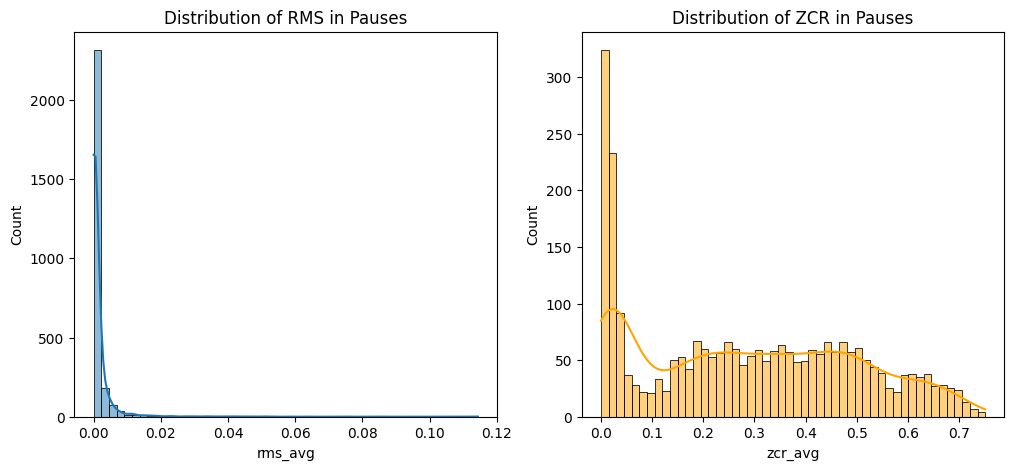

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Φτιάχνουμε ένα γράφημα για να δούμε πού χωρίζονται οι παύσεις
plt.figure(figsize=(12, 5))

# Γράφημα για το RMS
plt.subplot(1, 2, 1)
sns.histplot(pauses_only['rms_avg'], bins=50, kde=True)
plt.title('Distribution of RMS in Pauses')

# Γράφημα για το ZCR
plt.subplot(1, 2, 2)
sns.histplot(pauses_only['zcr_avg'], bins=50, kde=True, color='orange')
plt.title('Distribution of ZCR in Pauses')

plt.show()

In [ ]:
def final_breath_logic(row, voiced_limit):
    if row['Phoneme'] != 'pause':
        return 'speech'

    if row['Duration'] < 0.08:
        return "silent pause"

    # 3. Κανόνες για Ενέργεια και ZCR (για τις παύσεις που έχουν ικανή διάρκεια)
    is_not_silent = row['rms_avg'] > 0.00006
    is_below_speech = row['rms_avg'] < voiced_limit

    # Οι ανάσες είναι "breathy" αλλά όχι "fricative" (σύμφωνα)
    is_breathy_zcr = 0.10 < row['zcr_avg'] < 0.52
    is_centroid_ok = 2000 < row['sc_avg'] < 4800
    # Αν ικανοποιούνται όλα τα κριτήρια, είναι αναπνοή
    if is_not_silent and is_centroid_ok and is_below_speech and is_breathy_zcr:
        return "audible pause"

    # Σε κάθε άλλη περίπτωση παύσης, είναι σιωπή
    return "silent pause"

# Χρησιμοποιούμε το 0.005 ως voiced_limit (καλό compromise με βάση τα stats σου)
df_analysis['is_breath'] = df_analysis.apply(lambda r: final_breath_logic(r, 0.003), axis=1)

In [ ]:
df_analysis.is_breath.value_counts()

,count
is_breath,
speech,18216
silent pause,1530
audible pause,1150


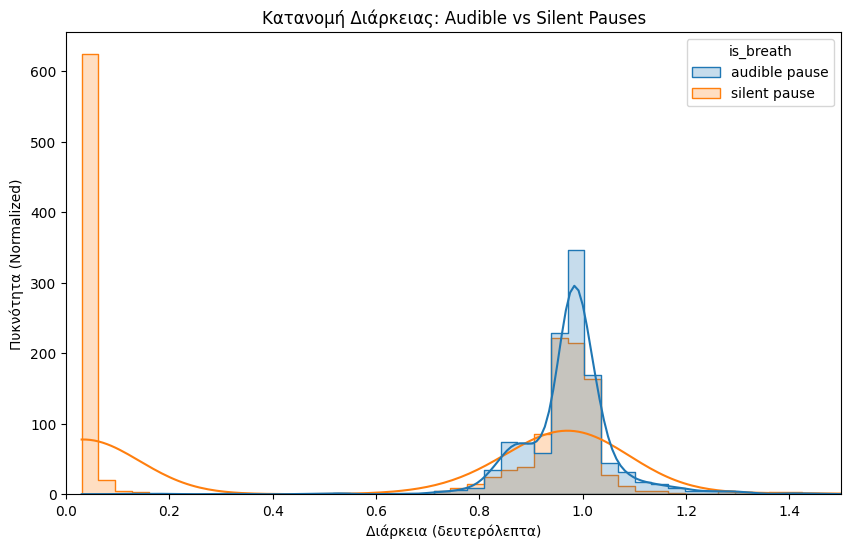

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Φιλτράρουμε μόνο τις παύσεις
pauses_df = df_analysis[df_analysis['Phoneme'] == 'pause']

plt.figure(figsize=(10, 6))

# Χρησιμοποιούμε common_norm=False γιατί οι σιωπές είναι υπερβολικά πολλές
# και θα "έπνιγαν" το γράφημα των αναπνοών
sns.histplot(data=pauses_df, x='Duration', hue='is_breath',
             element='step', common_norm=False, bins=50, kde=True)

plt.title('Κατανομή Διάρκειας: Audible vs Silent Pauses')
plt.xlabel('Διάρκεια (δευτερόλεπτα)')
plt.ylabel('Πυκνότητα (Normalized)')
plt.xlim(0, 1.5) # Περιορίζουμε τον άξονα Χ για να φαίνονται οι λεπτομέρειες
plt.show()

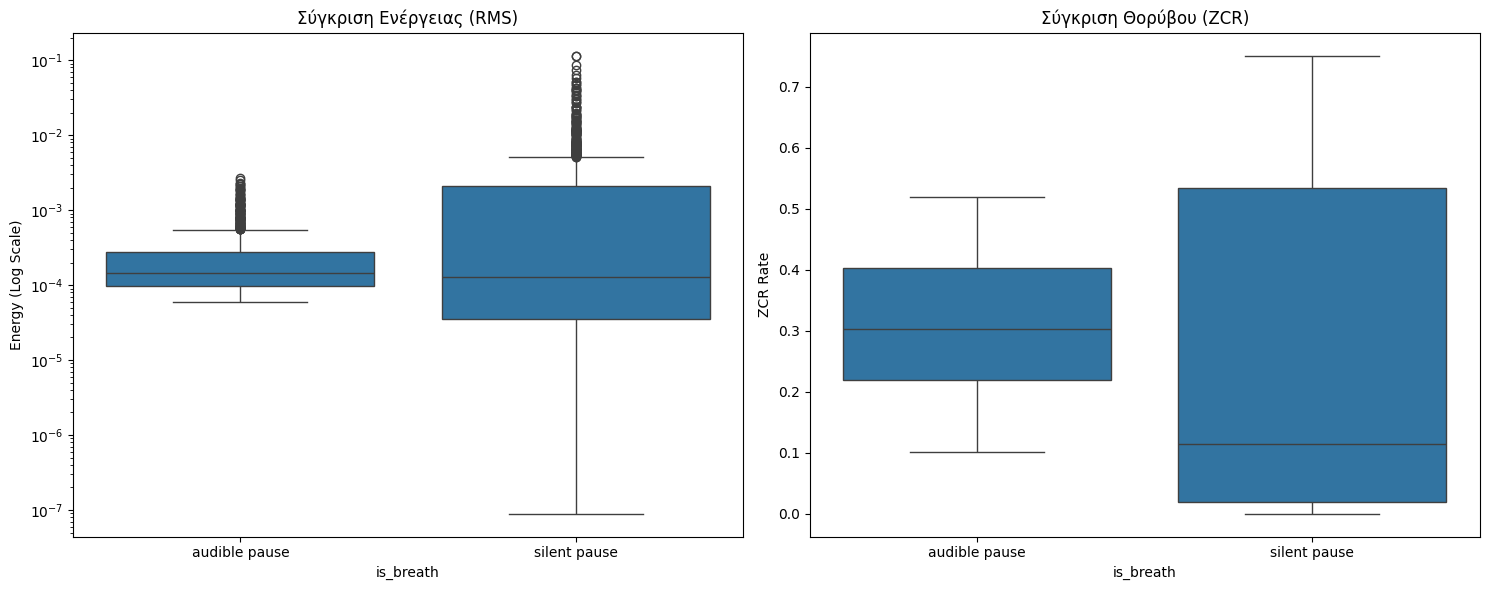

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Γράφημα για την Ενέργεια (RMS)
sns.boxplot(ax=axes[0], data=pauses_df, x='is_breath', y='rms_avg')
axes[0].set_yscale('log')
axes[0].set_title('Σύγκριση Ενέργειας (RMS)')
axes[0].set_ylabel('Energy (Log Scale)')

# Γράφημα για το Zero Crossing Rate (ZCR)
sns.boxplot(ax=axes[1], data=pauses_df, x='is_breath', y='zcr_avg')
axes[1].set_title('Σύγκριση Θορύβου (ZCR)')
axes[1].set_ylabel('ZCR Rate')

plt.tight_layout()
plt.show()

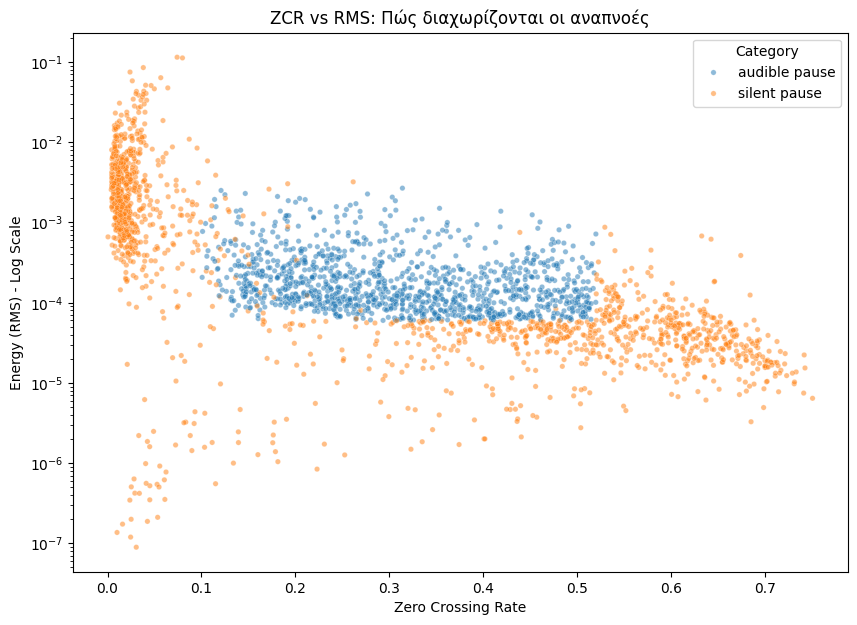

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(data=pauses_df, x='zcr_avg', y='rms_avg',
                hue='is_breath', alpha=0.5, s=15)

plt.yscale('log') # Η ενέργεια πάντα σε log για να βλέπουμε τη διαφορά
plt.title('ZCR vs RMS: Πώς διαχωρίζονται οι αναπνοές')
plt.xlabel('Zero Crossing Rate')
plt.ylabel('Energy (RMS) - Log Scale')
plt.legend(title='Category')
plt.show()

In [ ]:
from IPython.display import Audio
import librosa

random_idx = pauses_df.sample(n=1).index[0]
# Διάλεξε ένα index από το DataFrame σου (π.χ. από τις "ύποπτες" σιωπές)
row = pauses_df.loc[random_idx]

print(f"Ακούγοντας το {row['Phoneme']} - Κατηγορία: {row['is_breath']}")
print(f"RMS: {row['rms_avg']:.5f}, ZCR: {row['zcr_avg']:.5f}")

# Φορτώνουμε ΜΟΝΟ το συγκεκριμένο τμήμα
y, sr = librosa.load(row['full_path'], offset=row['Start time'], duration=row['Duration'])

# Εμφάνιση του player
Audio(y, rate=sr)

Ακούγοντας το pause - Κατηγορία: silent pause
RMS: 0.00002, ZCR: 0.67957


/tmp/ipykernel_2036/909675602.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analysis[df_analysis['Phoneme'] == 'pause'],


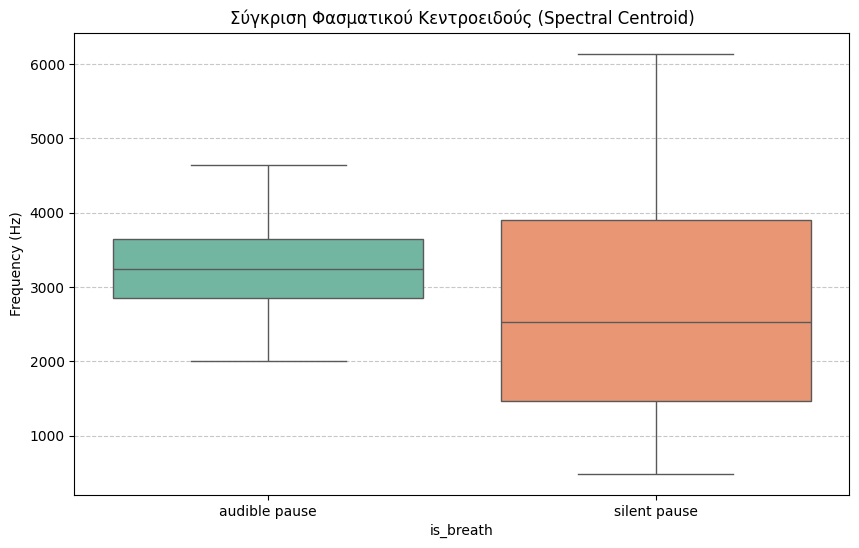

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_analysis[df_analysis['Phoneme'] == 'pause'],
            x='is_breath', y='sc_avg', palette='Set2')

plt.title('Σύγκριση Φασματικού Κεντροειδούς (Spectral Centroid)')
plt.ylabel('Frequency (Hz)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
df_analysis

,Filename,Phoneme,Start time,End time,Duration,Actor_id,full_path,zcr_avg,rms_avg,sc_avg,is_breath
0,03-02-06-02-02-02-08.wav,pause,0.00,1.02000,1.02000,Actor_08,/content/drive/MyDrive/RAVDESS/Actor_08/03-02-...,0.219549,0.000286,3239.117007,audible pause
1,03-02-06-02-02-02-08.wav,D,1.02,1.19000,0.17000,Actor_08,/content/drive/MyDrive/RAVDESS/Actor_08/03-02-...,0.224487,0.017068,3692.988893,speech
2,03-02-06-02-02-02-08.wav,AA1,1.19,1.30000,0.11000,Actor_08,/content/drive/MyDrive/RAVDESS/Actor_08/03-02-...,0.097266,0.057529,2094.210971,speech
3,03-02-06-02-02-02-08.wav,G,1.30,1.35000,0.05000,Actor_08,/content/drive/MyDrive/RAVDESS/Actor_08/03-02-...,0.051595,0.011547,2073.160519,speech
4,03-02-06-02-02-02-08.wav,Z,1.35,1.41000,0.06000,Actor_08,/content/drive/MyDrive/RAVDESS/Actor_08/03-02-...,0.305339,0.005545,6043.576865,speech
...,...,...,...,...,...,...,...,...,...,...,...
20891,03-02-06-02-02-02-13.wav,AH0,2.47,2.60000,0.13000,Actor_13,/content/drive/MyDrive/RAVDESS/Actor_13/03-02-...,0.043538,0.026478,1632.818705,speech
20892,03-02-06-02-02-02-13.wav,D,2.60,2.72000,0.12000,Actor_13,/content/drive/MyDrive/RAVDESS/Actor_13/03-02-...,0.064209,0.005502,2297.848938,speech
20893,03-02-06-02-02-02-13.wav,AO1,2.72,3.06000,0.34000,Actor_13,/content/drive/MyDrive/RAVDESS/Actor_13/03-02-...,0.050293,0.027155,1470.603351,speech
20894,03-02-06-02-02-02-13.wav,R,3.06,3.42000,0.36000,Actor_13,/content/drive/MyDrive/RAVDESS/Actor_13/03-02-...,0.049896,0.012379,1473.101698,speech


## extarct statistics

In [ ]:
import pandas as pd
import numpy as np

def extract_phoneme_features(filename, df):
    df_wav = df[df['Filename'] == filename].copy()
    if df_wav.empty:
        return {}

    ARPABET_VOWELS = {'AA', 'AE', 'AH', 'AO', 'AW', 'AY', 'EH', 'ER', 'EY', 'IH', 'IY', 'OW', 'OY', 'UH', 'UW'}

    def is_vowel(p):
        if pd.isna(p): return False
        # Αφαιρούμε τυχόν αριθμούς (π.χ. AA1 -> AA)
        clean_p = ''.join([i for i in str(p) if not i.isdigit()])
        return clean_p in ARPABET_VOWELS

    def calc_avg_dist(temp_df):
        if len(temp_df) < 2: return 0.0
        return temp_df['Start time'].diff().mean()


    # Only phonemes ignore pauses
    speech_df = df_wav[df_wav['Phoneme'] != 'pause'].copy()
    pauses_df = df_wav[df_wav['Phoneme'] == 'pause'].copy()
    total_pauses_count = len(pauses_df)

    # Basic time calculations
    total_duration = df_wav['Duration'].sum()
    vocalized_duration = speech_df['Duration'].sum()

    # Handle empty speech edge case (silence-only files)
    if speech_df.empty:
      return {k: 0.0 for k in [
        "phoneme_duration_cv",
        "articulation_rate",
        "vowel_ratio",
        "consonant_ratio",
        "avg_distance_pauses",
        "mean_phoneme_duration",
        "std_phoneme_duration",
        "pause_ratio",
        "mean_pause_dur",
        "std_pause_dur"
    ]}

    mean_dur = float(speech_df['Duration'].mean())
    std_dur = float(speech_df['Duration'].std() if len(speech_df) > 1 else 0.0)

    speech_df['is_vow'] = speech_df['Phoneme'].apply(is_vowel).copy()

    vowel_dur = speech_df[speech_df['is_vow']]['Duration'].sum()
    cons_dur = speech_df[~speech_df['is_vow']]['Duration'].sum()
    vowel_ratio = vowel_dur / vocalized_duration
    consonant_ratio = cons_dur / vocalized_duration

    mean_pause_dur = float(pauses_df['Duration'].mean())
    std_pause_dur = float(pauses_df['Duration'].std() if len(pauses_df) > 1 else 0.0)

    avg_dist_pauses = calc_avg_dist(pauses_df)

    # Feature Collection
    features = {
        "phoneme_duration_cv": std_dur / mean_dur if mean_dur > 0 else 0.0,
        "articulation_rate": len(speech_df) / vocalized_duration if vocalized_duration > 0 else 0.0,
        "vowel_ratio": vowel_ratio,
        "consonant_ratio": consonant_ratio,
        "avg_distance_pauses": avg_dist_pauses,
        "mean_phoneme_duration": mean_dur,
        "std_phoneme_duration": std_dur,
        "pause_ratio": pauses_df['Duration'].sum() / total_duration if total_duration > 0 else 0.0,
        "mean_pause_dur": mean_pause_dur,
        "std_pause_dur": std_pause_dur
    }

    # Clean any NaNs to 0.0 just in case
    return {k: (0.0 if pd.isna(v) else v) for k, v in features.items()}

In [ ]:
all_features = []
unique_files = df_analysis['Filename'].unique()

for fname in unique_files:
    f1 = extract_phoneme_features(fname, df_analysis)

    combined = {
        "filename": fname,
        **f1
    }
    all_features.append(combined)

df_phon = pd.DataFrame(all_features)


In [ ]:
df_phon.columns

Index(['filename', 'phoneme_duration_cv', 'articulation_rate', 'vowel_ratio',
       'consonant_ratio', 'avg_distance_pauses', 'mean_phoneme_duration',
       'std_phoneme_duration', 'pause_ratio', 'mean_pause_dur',
       'std_pause_dur'],
      dtype='object')

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mapping σύμφωνα με το documentation του RAVDESS
emotion_map = {
    1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad',
    5: 'angry', 6: 'fearful'
}
df_phon['emotion_label'] = df_phon['emotion'].map(emotion_map)

# Επιλογή χαρακτηριστικών που αφορούν τις παύσεις
pause_features = ['avg_distance_pauses', 'mean_pause_dur', 'std_pause_dur', 'vowel_ratio']

/tmp/ipykernel_2036/3594414799.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_phon, x='emotion_label', y=feature, palette='viridis')
/tmp/ipykernel_2036/3594414799.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_phon, x='emotion_label', y=feature, palette='viridis')
/tmp/ipykernel_2036/3594414799.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_phon, x='emotion_label', y=feature, palette='viridis')
/tmp/ipykernel_2036/3594414799.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated

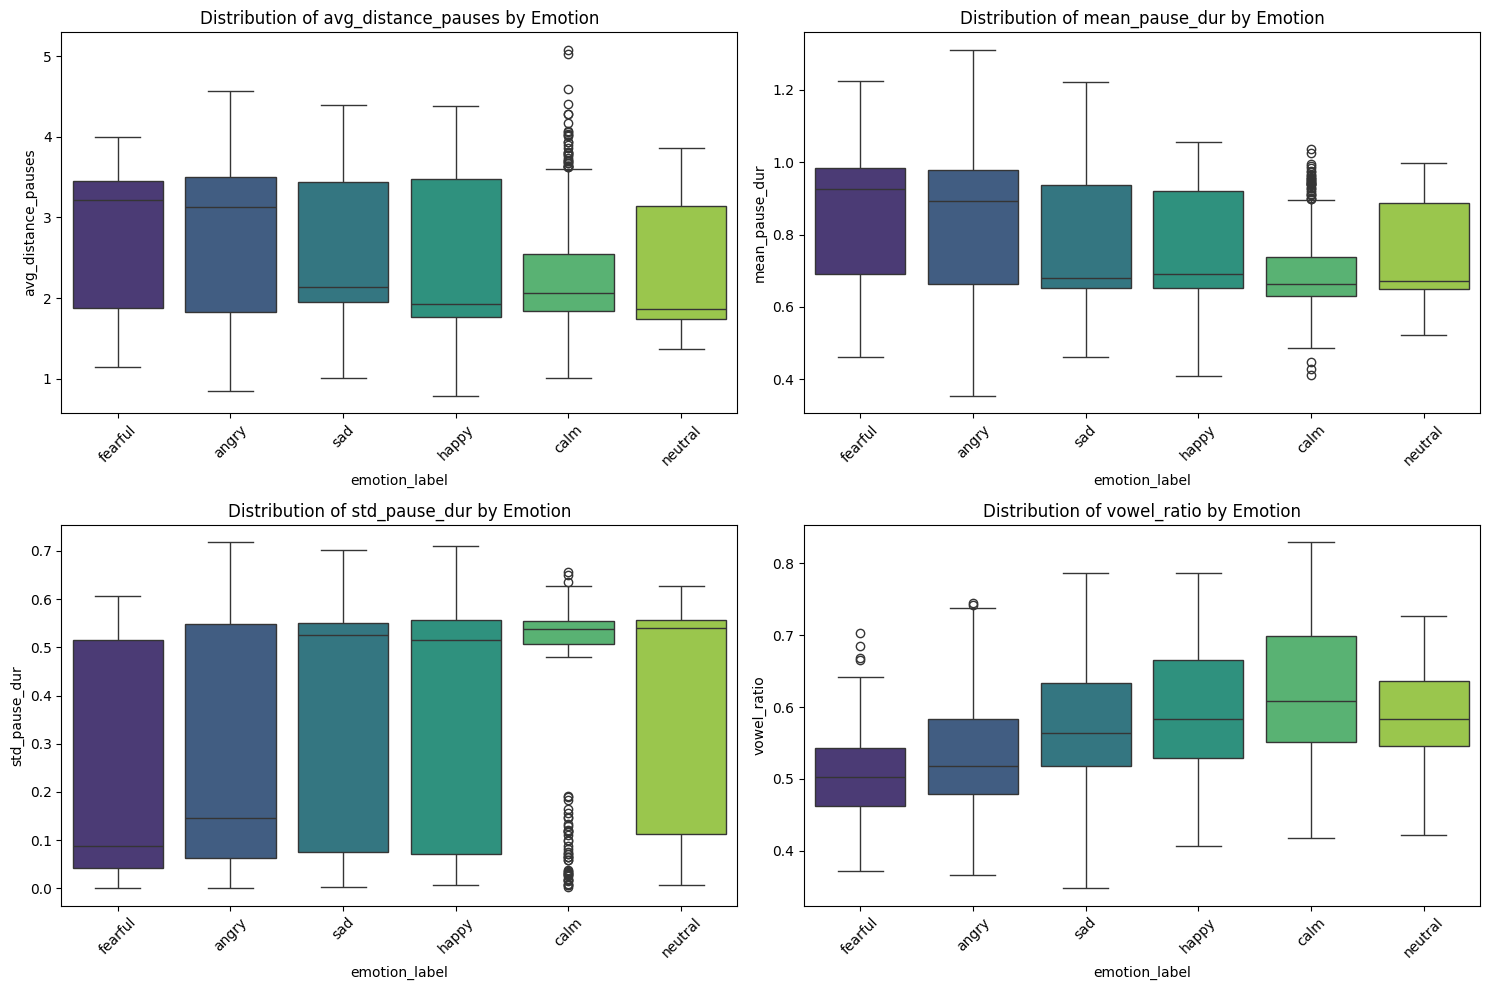

In [ ]:
plt.figure(figsize=(15, 10))

for i, feature in enumerate(pause_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df_phon, x='emotion_label', y=feature, palette='viridis')
    plt.title(f'Distribution of {feature} by Emotion')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Λίστα με τα χαρακτηριστικά που θέλουμε να ελέγξουμε
features_to_test = ['avg_distance_pauses', 'mean_pause_dur', 'vowel_ratio', 'std_pause_dur']

for feature in features_to_test:
    # 1. Κατασκευή του μοντέλου ANOVA
    model = ols(f'{feature} ~ C(emotion_label)', data=df_phon).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)

    p_value = anova_table['PR(>F)'][0]

    print(f"\n{'='*50}")
    print(f"ANOVA για το χαρακτηριστικό: {feature}")
    print(f"F-statistic: {anova_table['F'][0]:.4f}")
    print(f"p-value: {p_value:.4e}")

    # 2. Αν το αποτέλεσμα είναι σημαντικό (p < 0.05), κάνουμε Post-hoc test
    if p_value < 0.05:
        print(f"Το αποτέλεσμα είναι ΣΤΑΤΙΣΤΙΚΑ ΣΗΜΑΝΤΙΚΟ (p < 0.05)")

        # Tukey HSD για να δούμε ποια ζευγάρια διαφέρουν
        m_comp = pairwise_tukeyhsd(endog=df_phon[feature],
                                   groups=df_phon['emotion_label'],
                                   alpha=0.05)

        # Εμφάνιση μόνο των ζευγαριών που έχουν σημαντική διαφορά (reject=True)
        tukey_res = m_comp.summary()
        print("\nΣημαντικές διαφορές μεταξύ συναισθημάτων (Tukey HSD):")
        # Φιλτράρουμε για να δούμε μόνο τα True (δηλαδή όπου υπάρχει σημαντική διαφορά)
        print(m_comp)
    else:
        print("Δεν βρέθηκε στατιστικά σημαντική διαφορά.")

/tmp/ipykernel_2036/2945437998.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]
/tmp/ipykernel_2036/2945437998.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"F-statistic: {anova_table['F'][0]:.4f}")



ANOVA για το χαρακτηριστικό: avg_distance_pauses
F-statistic: 9.7498
p-value: 4.1372e-09
Το αποτέλεσμα είναι ΣΤΑΤΙΣΤΙΚΑ ΣΗΜΑΝΤΙΚΟ (p < 0.05)

Σημαντικές διαφορές μεταξύ συναισθημάτων (Tukey HSD):
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
  angry    calm  -0.3113 0.0092 -0.5728 -0.0498   True
  angry fearful   0.1834 0.3415 -0.0781   0.445  False
  angry   happy  -0.2037 0.2275 -0.4653  0.0578  False
  angry neutral  -0.4433 0.0012 -0.7636  -0.123   True
  angry     sad  -0.0709 0.9719 -0.3324  0.1906  False
   calm fearful   0.4947    0.0  0.2332  0.7563   True
   calm   happy   0.1076 0.8491  -0.154  0.3691  False
   calm neutral   -0.132 0.8479 -0.4523  0.1883  False
   calm     sad   0.2404 0.0923 -0.0211  0.5019  False
fearful   happy  -0.3871 0.0004 -0.6487 -0.1256   True
fearful neutral  -0.6267    0.0 -0.9471 -0.3064   True
fearful     sad  -0.2543 0.0621 -

/tmp/ipykernel_2036/2945437998.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]
/tmp/ipykernel_2036/2945437998.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"F-statistic: {anova_table['F'][0]:.4f}")



Σημαντικές διαφορές μεταξύ συναισθημάτων (Tukey HSD):
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
  angry    calm  -0.1238    0.0 -0.1724 -0.0753   True
  angry fearful   0.0542 0.0186  0.0056  0.1027   True
  angry   happy  -0.0584 0.0082 -0.1069 -0.0098   True
  angry neutral  -0.0876 0.0004 -0.1471 -0.0281   True
  angry     sad  -0.0445 0.0946  -0.093  0.0041  False
   calm fearful    0.178    0.0  0.1294  0.2265   True
   calm   happy   0.0655 0.0017  0.0169   0.114   True
   calm neutral   0.0362 0.5057 -0.0232  0.0957  False
   calm     sad   0.0794 0.0001  0.0308  0.1279   True
fearful   happy  -0.1125    0.0 -0.1611  -0.064   True
fearful neutral  -0.1417    0.0 -0.2012 -0.0823   True
fearful     sad  -0.0986    0.0 -0.1472 -0.0501   True
  happy neutral  -0.0292 0.7249 -0.0887  0.0302  False
  happy     sad   0.0139 0.9645 -0.0347  0.0624  False
neutral   

/tmp/ipykernel_2036/2945437998.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]
/tmp/ipykernel_2036/2945437998.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"F-statistic: {anova_table['F'][0]:.4f}")



Σημαντικές διαφορές μεταξύ συναισθημάτων (Tukey HSD):
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
  angry    calm   0.0927    0.0  0.0684   0.117   True
  angry fearful  -0.0233 0.0678 -0.0476  0.0009  False
  angry   happy    0.063    0.0  0.0387  0.0873   True
  angry neutral   0.0572    0.0  0.0274  0.0869   True
  angry     sad   0.0427    0.0  0.0184   0.067   True
   calm fearful  -0.1161    0.0 -0.1404 -0.0918   True
   calm   happy  -0.0297 0.0067  -0.054 -0.0054   True
   calm neutral  -0.0355 0.0088 -0.0653 -0.0058   True
   calm     sad  -0.0501    0.0 -0.0743 -0.0258   True
fearful   happy   0.0864    0.0  0.0621  0.1107   True
fearful neutral   0.0805    0.0  0.0508  0.1103   True
fearful     sad    0.066    0.0  0.0417  0.0903   True
  happy neutral  -0.0058 0.9934 -0.0356  0.0239  False
  happy     sad  -0.0204 0.1593 -0.0447  0.0039  False
neutral   

/tmp/ipykernel_2036/2945437998.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]
/tmp/ipykernel_2036/2945437998.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"F-statistic: {anova_table['F'][0]:.4f}")



Σημαντικές διαφορές μεταξύ συναισθημάτων (Tukey HSD):
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
  angry    calm    0.148    0.0  0.0795  0.2166   True
  angry fearful  -0.0824 0.0082  -0.151 -0.0139   True
  angry   happy    0.058 0.1523 -0.0106  0.1266  False
  angry neutral   0.1238 0.0004  0.0398  0.2077   True
  angry     sad   0.0702  0.041  0.0017  0.1388   True
   calm fearful  -0.2305    0.0 -0.2991 -0.1619   True
   calm   happy  -0.0901 0.0026 -0.1586 -0.0215   True
   calm neutral  -0.0243 0.9628 -0.1083  0.0597  False
   calm     sad  -0.0778 0.0156 -0.1464 -0.0092   True
fearful   happy   0.1404    0.0  0.0718   0.209   True
fearful neutral   0.2062    0.0  0.1222  0.2902   True
fearful     sad   0.1527    0.0  0.0841  0.2213   True
  happy neutral   0.0658 0.2223 -0.0182  0.1498  False
  happy     sad   0.0123 0.9958 -0.0563  0.0808  False
neutral   

In [ ]:
df_phon.to_csv('/content/drive/MyDrive/new_phonetic.csv', index=False)

In [ ]:
df_merged = df_final.merge(df_phon, on='filename', how='inner')


# z-speaker norm

In [ ]:
# Define which feature columns should be normalized
exclude_cols = ['filename', 'modality', 'vocal_channel', 'emotion', 'intensity',
       'statement', 'repetition', 'actor_id', 'gender', 'full_path']
feature_cols = [c for c in df_merged.columns if c not in exclude_cols and df_merged[c].dtype in ['float64', 'int64']]

def z_speaker_normalization(df, group_col, cols_to_norm):
    df_norm = df.copy()

    means = df_norm.groupby(group_col)[cols_to_norm].transform('mean')
    stds = df_norm.groupby(group_col)[cols_to_norm].transform('std')

   # Apply Z-score: (x - mean) / std
   # Add a very small number (1e-9) to the denominator to avoid division by zero
    df_norm[cols_to_norm] = (df_norm[cols_to_norm] - means) / (stds + 1e-9)

    return df_norm

df_normalized = z_speaker_normalization(df_merged, group_col='actor_id', cols_to_norm=feature_cols)

In [ ]:
df_normalized.describe()

,modality,vocal_channel,emotion,intensity,statement,repetition,actor_id,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,...,phoneme_duration_cv,articulation_rate,vowel_ratio,consonant_ratio,avg_distance_pauses,mean_phoneme_duration,std_phoneme_duration,pause_ratio,mean_pause_dur,std_pause_dur
count,1012.0,1012.0,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1.012000e+03,1.012000e+03,1.012000e+03,...,1.012000e+03,1.012000e+03,1.012000e+03,1.012000e+03,1.012000e+03,1.012000e+03,1.012000e+03,1.012000e+03,1.012000e+03,1.012000e+03
mean,3.0,2.0,3.727273,1.454545,1.500000,1.500000,12.260870,1.331390e-15,-1.448117e-17,1.377028e-15,...,8.249879e-17,-9.478584e-17,-1.983481e-16,-1.088282e-16,-8.864231e-17,1.263811e-16,-1.404235e-17,3.686116e-16,-9.390819e-17,5.265880e-18
std,0.0,0.0,1.601411,0.498176,0.500247,0.500247,6.976797,9.890598e-01,9.890598e-01,9.890598e-01,...,9.890598e-01,9.890598e-01,9.890598e-01,9.890598e-01,9.890598e-01,9.890598e-01,9.890598e-01,9.890598e-01,9.890598e-01,9.890598e-01
min,3.0,2.0,1.000000,1.000000,1.000000,1.000000,1.000000,-3.675873e+00,-1.697351e+00,-4.243271e+00,...,-2.570889e+00,-3.010321e+00,-2.847684e+00,-4.221075e+00,-5.371400e+00,-2.602951e+00,-2.345352e+00,-3.602489e+00,-5.473060e+00,-4.514043e+00
25%,3.0,2.0,2.000000,1.000000,1.000000,1.000000,6.000000,-5.414579e-01,-6.436296e-01,-5.491264e-01,...,-6.950730e-01,-6.935193e-01,-7.629254e-01,-7.055630e-01,-6.782596e-01,-6.925284e-01,-6.758368e-01,-6.781561e-01,-6.423790e-01,-7.285355e-01
50%,3.0,2.0,4.000000,1.000000,1.500000,1.500000,12.000000,5.244014e-02,-2.779613e-01,1.762953e-01,...,-1.829724e-01,7.028690e-02,1.056210e-02,-1.056210e-02,-1.203389e-01,-1.800517e-01,-1.978765e-01,8.035114e-02,-7.567138e-02,2.585462e-01
75%,3.0,2.0,5.000000,2.000000,2.000000,2.000000,19.000000,5.563494e-01,4.613478e-01,6.700886e-01,...,6.387895e-01,6.813482e-01,7.055630e-01,7.629254e-01,6.786308e-01,6.332027e-01,5.737222e-01,6.825587e-01,6.898848e-01,6.558616e-01
max,3.0,2.0,6.000000,2.000000,2.000000,2.000000,24.000000,3.531430e+00,4.700712e+00,2.275523e+00,...,5.723261e+00,3.408776e+00,4.221075e+00,2.847684e+00,4.337930e+00,3.865446e+00,5.356281e+00,2.982738e+00,4.558633e+00,5.694793e+00


In [ ]:
df_normalized.to_csv('/content/drive/MyDrive/df_ravdess_normv2full.csv', index=False)

In [ ]:
df_normalized.to_csv('/content/drive/MyDrive/df_ravdess_normv3full.csv', index=False)

# VocalSet

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
vocal_set = pd.read_csv('/content/drive/MyDrive/vocalset_norm_check5.csv')

Calculating durations: 100%|██████████| 2579/2579 [11:57<00:00,  3.59it/s]



=== Στατιστικά Διάρκειας (δευτερόλεπτα) ===
count    2579.000000
mean        8.581354
std         5.654791
min         1.620476
25%         4.700159
50%         7.950544
75%        10.542925
max        48.102449
Name: duration, dtype: float64

=== Ποσοστημόρια (Percentiles) ===
0.90    13.865469
0.95    17.997921
0.99    36.943392
Name: duration, dtype: float64


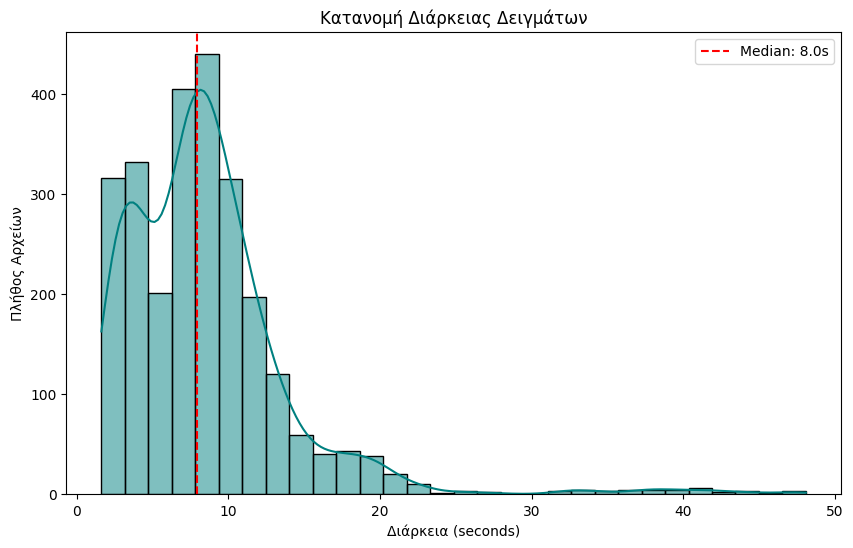

In [ ]:
import librosa
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Ενεργοποιούμε το tqdm για τα pandas για να βλέπουμε μπάρα προόδου
tqdm.pandas(desc="Calculating durations")

# 1. Υπολογισμός διάρκειας για κάθε path στο df
# Χρησιμοποιούμε try-except για την περίπτωση που κάποιο αρχείο είναι κατεστραμμένο
def get_file_duration(path):
    try:
        return librosa.get_duration(path=path)
    except:
        return None

# Δημιουργία νέας στήλης 'duration'
vocal_set['duration'] = vocal_set['full_path'].progress_apply(get_file_duration)

# 2. Βασικές Στατιστικές
print("\n=== Στατιστικά Διάρκειας (δευτερόλεπτα) ===")
stats = vocal_set['duration'].describe()
percentiles = vocal_set['duration'].quantile([0.90, 0.95, 0.99])
print(stats)
print("\n=== Ποσοστημόρια (Percentiles) ===")
print(percentiles)

# 3. Οπτικοποίηση (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(vocal_set['duration'].dropna(), bins=30, kde=True, color='teal')
plt.axvline(vocal_set['duration'].median(), color='red', linestyle='--', label=f'Median: {vocal_set['duration'].median():.1f}s')
plt.title('Κατανομή Διάρκειας Δειγμάτων')
plt.xlabel('Διάρκεια (seconds)')
plt.ylabel('Πλήθος Αρχείων')
plt.legend()
plt.show()

In [ ]:
df_outliers.technique.value_counts()

,count
technique,
straight_tone,43
vibrato,42
MessaDiVoce,16
slow_legato_piano,11
trill,11
slow_legato_forte,4
trillo,2


In [ ]:
# 1. Υπολογίζουμε το ακριβές όριο του 95%
threshold_95 = vocal_set['duration'].quantile(0.95)
print(f"Το όριο του 95% είναι τα {threshold_95:.2f} δευτερόλεπτα.")

# 2. Φιλτράρουμε το DataFrame
# Κρατάμε όσα είναι μικρότερα ή ίσα με το όριο
df_clean = vocal_set[vocal_set['duration'] <= threshold_95].copy()

# 3. Αποθηκεύουμε τα outliers σε ένα ξεχωριστό DF (προαιρετικά, για έλεγχο)
df_outliers = vocal_set[vocal_set['duration'] > threshold_95].copy()

# 4. Έλεγχος αποτελεσμάτων
print(f"Αρχικά δείγματα: {len(vocal_set)}")
print(f"Δείγματα που αφαιρέθηκαν: {len(df_outliers)}")
print(f"Νέο σύνολο δειγμάτων: {len(df_clean)}")
print(f"Νέα μέση διάρκεια: {df_clean['duration'].mean():.2f}s")

Το όριο του 95% είναι τα 18.00 δευτερόλεπτα.
Αρχικά δείγματα: 2579
Δείγματα που αφαιρέθηκαν: 129
Νέο σύνολο δειγμάτων: 2450
Νέα μέση διάρκεια: 7.68s


In [ ]:
!pip install crepe opensmile

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 36.2 MB/s eta 0:00:00
  Created wheel for crepe: filename=crepe-0.0.16-py3-none-any.whl size=134848677 sha256=0d945b41990aad32be8713bb3c8c976a922dedf137d87a49e48c4e5d5046df87
  Stored in directory: /root/.cache/pip/wheels/36/fb/4f/4357617f155cf882b996fb4ee50a2863343262

In [ ]:
import numpy as np
import librosa
import crepe
import os

def extract_extra_features(y, sr):

    # ---------- Spectral Flatness ----------
    flatness = librosa.feature.spectral_flatness(y=y)[0]
    spectral_flatness_mean = np.mean(flatness)
    spectral_flatness_std = np.std(flatness)

    # ---------- Spectral Centroid ----------
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    spectral_centroid_mean = np.mean(centroid)
    spectral_centroid_std = np.std(centroid)

    # ---------- Zero Crossing Rate (ZCR) ----------
    zcr = librosa.feature.zero_crossing_rate(y=y)[0]
    zcr_mean = np.mean(zcr)
    zcr_std = np.std(zcr)

    # ---------- Loudness (RMS) & Energy ----------
    rms = librosa.feature.rms(y=y)[0]
    st_loud_var = np.mean(np.abs(np.diff(rms)))
    lt_loud_var = np.max(rms) - np.min(rms)
    delta_energy = np.diff(rms)

    try:
        # CREPE Pitch Tracking
        time, f0, conf, _ = crepe.predict(y, sr, model_capacity="medium", step_size=10, verbose=False)

        f0_flat = f0.flatten()
        conf_flat = conf.flatten()

        # Κρατάμε τα valid frames για τα συνολικά features (DETT, variability κλπ)
        mask = conf_flat > 0.7
        f0_voiced = f0_flat[mask]

        if len(f0_voiced) > 10:
            st = 12 * np.log2(f0_voiced / 440.0)

            # 1. Melodic & Variability Features (Συνολικά για το αρχείο)
            pitch_variability = np.std(st)
            melodic_deviation = np.mean(np.abs(st - np.mean(st)))

            # 2. Absolute DETT
            abs_dett_array = np.abs(st - np.round(st))
            dett_mean = np.mean(abs_dett_array)
            dett_sd = np.std(abs_dett_array)

            # 3. Signed DETT
            signed_dett_array = st - np.round(st)
            pitch_bias = np.mean(signed_dett_array)

            # 4. Coefficient of Variation
            dett_cv = dett_sd / dett_mean if dett_mean > 0 else 0

            # 5. Delta Pitch
            delta_pitch = np.diff(st)
            delta_pitch_mean = np.mean(delta_pitch)
            delta_pitch_std = np.std(delta_pitch)

            # Segmentation Logic for MFDR
            segments = []
            current_segment = []

            for val, c in zip(f0_flat, conf_flat):
                if c > 0.7:
                    current_segment.append(val)
                else:
                    if len(current_segment) >= 20: # Τουλάχιστον 200ms
                        segments.append(np.array(current_segment))
                    current_segment = []

            if len(current_segment) >= 20:
                segments.append(np.array(current_segment))

            # Υπολογισμός MFDR ανά segment και μέσος όρος
            mfdr_list = []
            for seg in segments:
                res = compute_mfdr_singing(seg, conf=None, step_size_ms=10)
                if not np.isnan(res["MFDR_slow"]):
                    mfdr_list.append(res)

            if mfdr_list:
                mfdr_features = {}
                for key in mfdr_list[0].keys():
                    mfdr_features[key] = np.mean([r[key] for r in mfdr_list])
            else:
                mfdr_features = {k: np.nan for k in ["MFDR_slow", "MFDR_vibrato", "MFDR_high", "MFDR_slow2vibrato", "MFDR_vibrato2high"]}

        else:
            melodic_deviation = pitch_variability = dett_mean = dett_sd = pitch_bias = dett_cv = delta_pitch_mean = delta_pitch_std = np.nan
            mfdr_features = {k: np.nan for k in ["MFDR_slow", "MFDR_vibrato", "MFDR_high", "MFDR_slow2vibrato", "MFDR_vibrato2high"]}

    except Exception as e:
        print(f"CREPE error: {e}")
        melodic_deviation = pitch_variability = dett_mean = dett_sd = pitch_bias = delta_pitch_mean = delta_pitch_std = dett_cv = np.nan
        mfdr_features = {k: np.nan for k in ["MFDR_slow", "MFDR_vibrato", "MFDR_high", "MFDR_slow2vibrato", "MFDR_vibrato2high"]}

    return {
        "melodic_deviation": melodic_deviation,
        "pitch_variability": pitch_variability,
        "dett_mean": dett_mean,
        "dett_std": dett_sd,
        "dett_cv": dett_cv,
        "pitch_bias": pitch_bias,
        "delta_pitch_mean": delta_pitch_mean,
        "delta_pitch_std": delta_pitch_std,
        "spectral_flatness_mean": spectral_flatness_mean,
        "spectral_flatness_std": spectral_flatness_std,
        "spectral_centroid_mean": spectral_centroid_mean,
        "spectral_centroid_std": spectral_centroid_std,
        "st_loudness_variability": st_loud_var,
        "lt_loudness_variability": lt_loud_var,
        "zcr_mean": zcr_mean,
        "zcr_std": zcr_std,
        "delta_energy_mean": np.mean(delta_energy),
        "delta_energy_std": np.std(delta_energy),
        **mfdr_features
    }

In [ ]:
import numpy as np
import librosa
import crepe
import os

# deviation from nearest semitone center, used as a proxy for intonation stability in emotional singing
# score-independent intonation descriptors

def extract_extra_features(y, sr):

    # ---------- Spectral Flatness ----------
    flatness = librosa.feature.spectral_flatness(y=y)[0]
    spectral_flatness_mean = np.mean(flatness)
    spectral_flatness_std = np.std(flatness)

    # ---------- Spectral Centroid ----------
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    spectral_centroid_mean = np.mean(centroid)
    spectral_centroid_std = np.std(centroid)

    # ---------- Zero Crossing Rate (ZCR) ----------
    zcr = librosa.feature.zero_crossing_rate(y=y)[0]
    zcr_mean = np.mean(zcr) # Υπολογισμός μόνο στον ήχο
    zcr_std = np.std(zcr)

    # ---------- Loudness (RMS) & Energy ----------
    rms = librosa.feature.rms(y=y)[0]
    st_loud_var = np.mean(np.abs(np.diff(rms)))
    lt_loud_var = np.max(rms) - np.min(rms)
    delta_energy = np.diff(rms)

    try:
        # CREPE Pitch Tracking
        time, f0, conf, _ = crepe.predict(y, sr, model_capacity="medium", step_size=10, verbose=False)

        f0 = f0.flatten()
        conf = conf.flatten()
        mask = conf > 0.7
        f0 = f0[mask]

        if len(f0) > 10:
            st = 12 * np.log2(f0 / 440.0)

            # 1. Melodic & Variability Features
            pitch_variability = np.std(st)
            melodic_deviation = np.mean(np.abs(st - np.mean(st)))

            # 2. Absolute DETT (Total Instability/Shakiness)
            abs_dett_array = np.abs(st - np.round(st))
            dett_mean = np.mean(abs_dett_array)
            dett_sd = np.std(abs_dett_array)

            # 3. Signed DETT (Pitch Bias: Sharp vs. Flat)
            signed_dett_array = st - np.round(st)
            pitch_bias = np.mean(signed_dett_array)

            # 4. Coefficient of Variation (Sharpness of Error)
            dett_cv = dett_sd / dett_mean if dett_mean > 0 else 0

            delta_pitch = np.diff(st)
            delta_pitch_mean = np.mean(delta_pitch)
            delta_pitch_std = np.std(delta_pitch)

        else:
            melodic_deviation = pitch_variability = dett_mean = dett_sd = pitch_bias = dett_cv = delta_pitch_mean = delta_pitch_std = np.nan

    except Exception as e:
        print(f"CREPE error on {file_path}: {e}")
        melodic_deviation = pitch_variability = dett_mean = dett_sd = pitch_bias = delta_pitch_mean = delta_pitch_std = dett_cv = np.nan

    # RETURN DICTIONARY (Names now match perfectly)
    return {
        "melodic_deviation": melodic_deviation,
        "pitch_variability": pitch_variability,
        "dett_mean": dett_mean,
        "dett_std": dett_sd,
        "dett_cv": dett_cv,
        "pitch_bias": pitch_bias,
        "delta_pitch_mean": delta_pitch_mean,
        "delta_pitch_std": delta_pitch_std,
        "spectral_flatness_mean": spectral_flatness_mean,
        "spectral_flatness_std": spectral_flatness_std,
        "spectral_centroid_mean": spectral_centroid_mean,
        "spectral_centroid_std": spectral_centroid_std,
        "st_loudness_variability": st_loud_var,
        "lt_loudness_variability": lt_loud_var,
        "zcr_mean": zcr_mean,
        "zcr_std": zcr_std,
        "delta_energy_mean": np.mean(delta_energy),
        "delta_energy_std": np.std(delta_energy)
    }

In [ ]:
import re
import librosa
import numpy as np
from tqdm import tqdm
import glob
import pandas as pd
import opensmile
import os

# Ρύθμιση OpenSMILE
smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.Functionals
)

target_sr = 22050
all_features = []
drive_path = "/content/drive/MyDrive/VocalSet2/**/*.wav"
files = glob.glob(drive_path, recursive=True)

for wave_file in tqdm(files, desc="Processing files"):
    filename = os.path.basename(wave_file)

    # Regex για το speaker id (f1, m2 κτλ)
    match = re.search(r'^([fm]\d{1,2})', filename.lower())
    if not match:
        continue

    speaker_id = match.group(1)
    # Η τεχνική συνήθως είναι το όνομα του φακέλου
    technique = os.path.basename(os.path.dirname(wave_file))

    try:
        # 1. Φόρτωση και Resampling μία φορά
        # Χωρίς trim, χωρίς normalize (όπως είπαμε για το CNN consistency)
        y, sr = librosa.load(wave_file, sr=target_sr)

        # 2. OpenSMILE features από το σήμα (signal)
        # Χρησιμοποιούμε το process_signal αντί για process_file
        res_smile = smile.process_signal(y, sr)
        opensmile_features = res_smile.iloc[0].to_dict()

        # 3. Extra features (πρέπει η συνάρτηση να δέχεται πλέον y, sr)
        extra_features = extract_extra_features(y, sr)

        # Συνδυασμός δεδομένων
        combined_features = {
            "filename": filename,
            "speaker_id": speaker_id,
            "technique": technique,
            "full_path": wave_file,
            **opensmile_features,
            **extra_features
        }

        all_features.append(combined_features)

    except Exception as e:
        print(f" Error for {wave_file}: {e}")
        continue

# Δημιουργία DataFrame
df_features = pd.DataFrame(all_features)

# Αποθήκευση
save_path = "/content/drive/MyDrive/vocalset_featuresv2_check1.csv"
df_features.to_csv(save_path, index=False)

print(f"\nProcessing complete! {len(df_features)} samples created.")

Processing files: 100%|██████████| 3406/3406 [1:13:10<00:00,  1.29s/it]



Processing complete! 3375 samples created.


In [ ]:
import re
from tqdm import tqdm
import pandas as pd
import os
import numpy as np

all_features = []

# Assuming df_vocalset is already loaded and contains the 'full_path' column
# We iterate directly over the values in that column
for wave_file in tqdm(vocal_set['full_path'], desc="Processing files"):

    if not isinstance(wave_file, str) or not os.path.exists(wave_file):
        continue

    filename = os.path.basename(wave_file)

    # Extract speaker id (e.g. f1, f10, m2, m11)
    match = re.search(r'^([fm]\d{1,2})', filename.lower())
    if not match:
        continue

    speaker_id = match.group(1)

    # Extract technique from the parent directory name
    technique = os.path.basename(os.path.dirname(wave_file))

    # --- Feature Extraction ---
    try:
        extra_features = extract_extra_features_v2(wave_file)

    except Exception as e:
        print(f"Error for {wave_file}: {e}")
        continue

    # Combine metadata with extracted features
    combined_features = {
        "speaker_id": speaker_id,
        "technique": technique,
        "full_path": wave_file,
        **extra_features
    }

    all_features.append(combined_features)

df_features = pd.DataFrame(all_features)

print(f"\nProcessing complete! {len(df_features)} samples created.")

Processing files: 100%|██████████| 2579/2579 [39:24<00:00,  1.09it/s]


Processing complete! 2579 samples created.


In [ ]:
df_features.dropna(subset=['MFDR_high'], inplace=True)

In [ ]:
df_features.to_csv('/content/drive/MyDrive/vocalset_dett.csv', index=False)


/tmp/ipykernel_2847/24143272.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


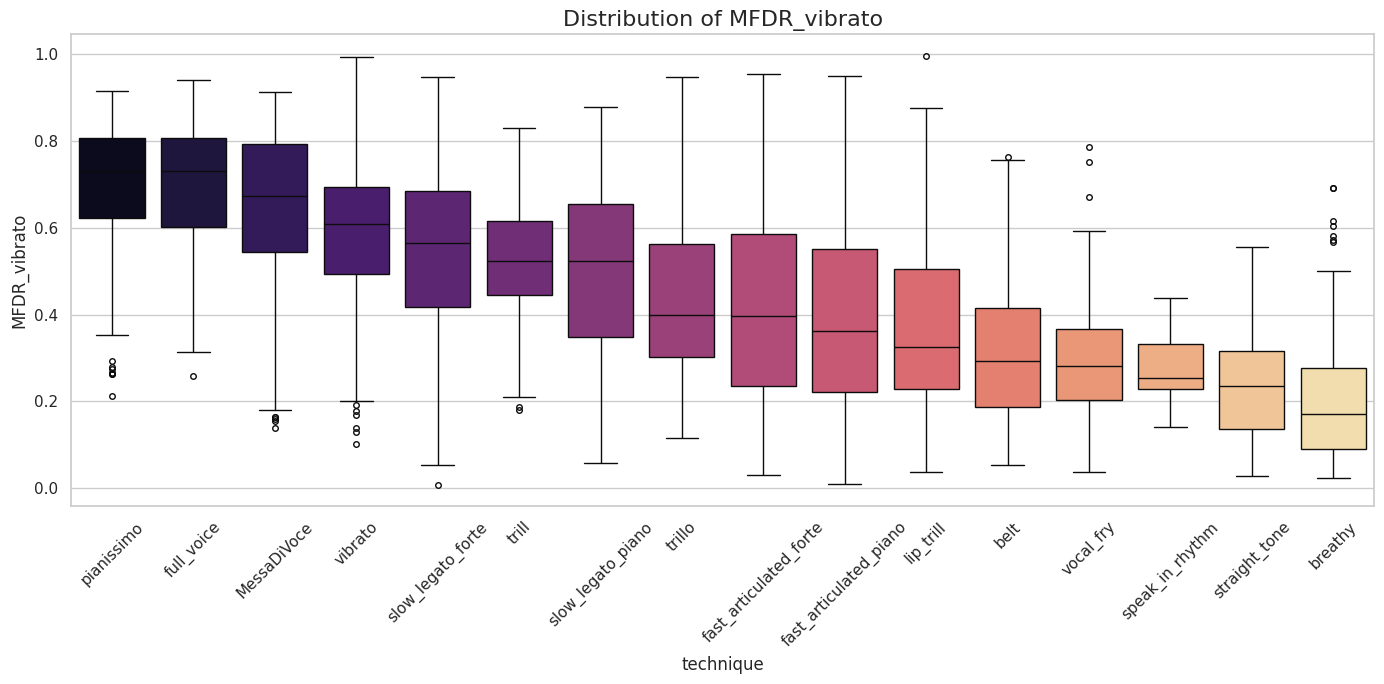

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# 1. Set the visual style
sns.set_theme(style="whitegrid")

# 2. Sort techniques by median for a cleaner look
tech_order = df_features.groupby('technique')['MFDR_vibrato'].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 7))

# 3. Create the Box Plot
sns.boxplot(
    data=df_features,
    x='technique',
    y='MFDR_vibrato',
    order=tech_order,
    palette='magma',
    fliersize=4 # Size of outlier dots
)

plt.title('Distribution of MFDR_vibrato', fontsize=16)
plt.xticks(rotation=45)
plt.ylabel('MFDR_vibrato')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2847/1970342575.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


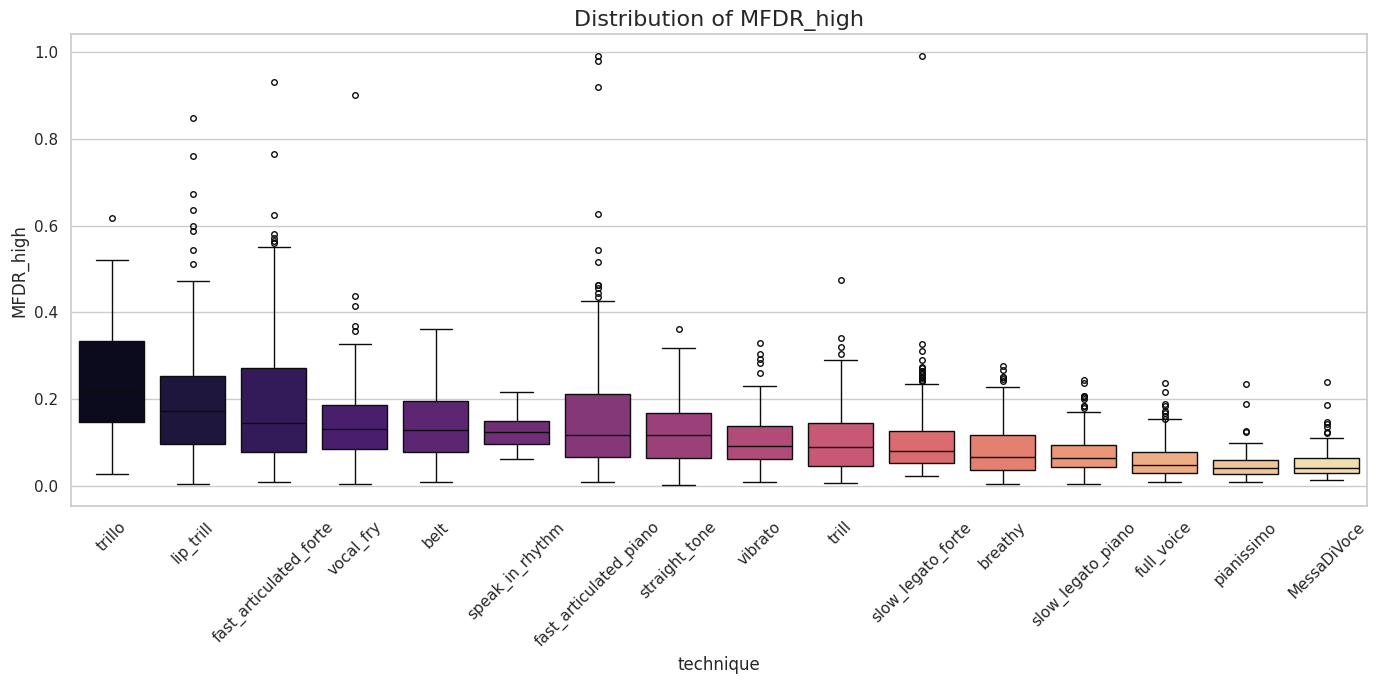

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# 1. Set the visual style
sns.set_theme(style="whitegrid")

# 2. Sort techniques by median for a cleaner look
tech_order = df_features.groupby('technique')['MFDR_high'].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 7))

# 3. Create the Box Plot
sns.boxplot(
    data=df_features,
    x='technique',
    y='MFDR_high',
    order=tech_order,
    palette='magma',
    fliersize=4 # Size of outlier dots
)

plt.title('Distribution of MFDR_high', fontsize=16)
plt.xticks(rotation=45)
plt.ylabel('MFDR_high')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6413/3929874964.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


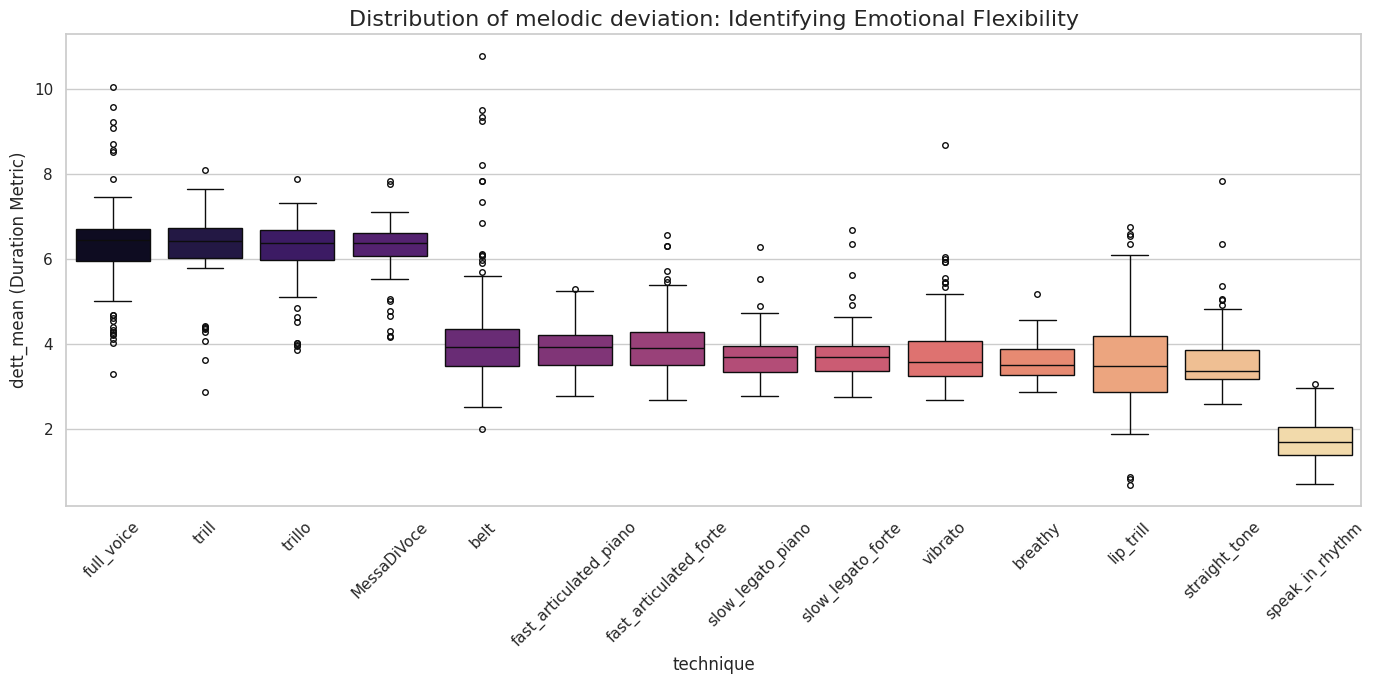

In [ ]:
# 1. Set the visual style
sns.set_theme(style="whitegrid")

# 2. Sort techniques by median for a cleaner look
tech_order = df_features.groupby('technique')['melodic_deviation'].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 7))

# 3. Create the Box Plot
sns.boxplot(
    data=df_features,
    x='technique',
    y='melodic_deviation',
    order=tech_order,
    palette='magma',
    fliersize=4 # Size of outlier dots
)

plt.title('Distribution of melodic deviation: Identifying Emotional Flexibility', fontsize=16)
plt.xticks(rotation=45)
plt.ylabel('dett_mean (Duration Metric)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6413/1550432423.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


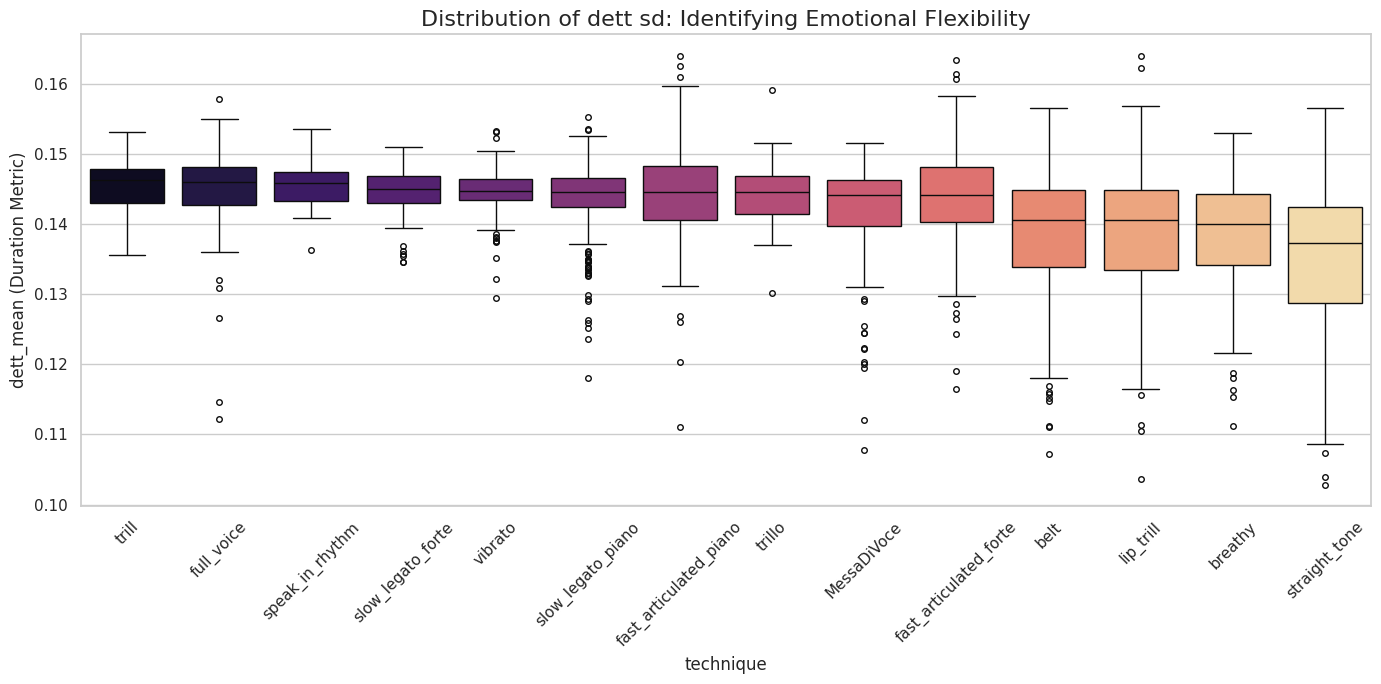

In [ ]:
# 1. Set the visual style
sns.set_theme(style="whitegrid")

# 2. Sort techniques by median for a cleaner look
tech_order = df_features.groupby('technique')['dett_sd'].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 7))

# 3. Create the Box Plot
sns.boxplot(
    data=df_features,
    x='technique',
    y='dett_sd',
    order=tech_order,
    palette='magma',
    fliersize=4 # Size of outlier dots
)

plt.title('Distribution of dett sd: Identifying Emotional Flexibility', fontsize=16)
plt.xticks(rotation=45)
plt.ylabel('dett_mean (Duration Metric)')
plt.tight_layout()
plt.show()

#cnn

In [ ]:
import librosa
import numpy as np
from tqdm import tqdm
import glob

target_sr = 22050
n_mels = 160
hop_length = 256
n_fft = 2048
target_frames = 128
target_samples = target_frames * hop_length

all_mel_chunks = []
all_pitch_chunks = []
chunk_metadata = []

files = glob.glob("/content/drive/MyDrive/VocalSet2/**/*.wav", recursive=True)

for path in tqdm(files):
    try:
        y, _ = librosa.load(path, sr=target_sr)
    except Exception as e:
        print(f"Error loading {path}: {e}")
        continue

    total_samples = len(y)

    for start_sample in range(0, total_samples, target_samples):
        end_sample = start_sample + target_samples
        chunk_audio = y[start_sample:end_sample]

        if len(chunk_audio) < target_samples:
            if len(chunk_audio) / target_samples < 0.3: continue
            chunk_audio = np.pad(chunk_audio, (0, target_samples - len(chunk_audio)), mode='constant')

        # 1. Mel-Spectrogram
        S = librosa.feature.melspectrogram(y=chunk_audio, sr=target_sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
        S_dB = librosa.power_to_db(S, ref=np.max)

        # Resize/Fix frames to 128
        if S_dB.shape[1] > target_frames: S_dB = S_dB[:, :target_frames]
        elif S_dB.shape[1] < target_frames: S_dB = np.pad(S_dB, ((0, 0), (0, target_frames - S_dB.shape[1])))

        S_norm = np.clip((S_dB + 80) / 80, 0, 1)

        # 2. Pitch Contour (YIN)
        f0 = librosa.yin(y=chunk_audio, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'),
                         sr=target_sr, hop_length=hop_length)

        f0_norm = np.clip(f0 / librosa.note_to_hz('C7'), 0, 1)

        if len(f0_norm) > target_frames: f0_norm = f0_norm[:target_frames]
        elif len(f0_norm) < target_frames: f0_norm = np.pad(f0_norm, (0, target_frames - len(f0_norm)))

        all_mel_chunks.append(S_norm)
        all_pitch_chunks.append(f0_norm)
        chunk_metadata.append(path)

X_mel_new = np.array(all_mel_chunks)[..., np.newaxis]
X_pitch_new = np.array(all_pitch_chunks)[..., np.newaxis]

print(f"\nΈτοιμα {len(X_mel_new)} chunks για πρόβλεψη!")


100%|██████████| 3406/3406 [08:31<00:00,  6.66it/s]



Έτοιμα 20920 chunks για πρόβλεψη!


In [ ]:
chunk_metadata[7000]

'/content/drive/MyDrive/VocalSet2/other/slow_legato_forte/m4_scales_f_slow_forte_a.wav'

In [ ]:
import tensorflow as tf
import pandas as pd

model = tf.keras.models.load_model("model_pitch_leaky (1).h5")
predictions = model.predict([X_mel_new, X_pitch_new])

df_tech_features = pd.DataFrame(predictions, columns=['mix', 'falsetto', 'breathy', 'pharyngeal', 'glissando', 'vibrato'])
df_tech_features['full_path'] = chunk_metadata

654/654 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step


In [ ]:
df_tech_features

,mix,falsetto,breathy,pharyngeal,glissando,vibrato,full_path
0,0.455659,0.126191,0.180793,0.323855,0.487259,0.476524,/content/drive/MyDrive/VocalSet2/vibrato/f9_ro...
1,0.495453,0.090701,0.122182,0.433778,0.484433,0.549194,/content/drive/MyDrive/VocalSet2/vibrato/f9_ro...
2,0.391878,0.064462,0.097740,0.501121,0.383565,0.450299,/content/drive/MyDrive/VocalSet2/vibrato/f9_ro...
3,0.385434,0.046267,0.072913,0.549886,0.438337,0.593317,/content/drive/MyDrive/VocalSet2/vibrato/f9_ro...
4,0.426718,0.077350,0.113007,0.557088,0.428513,0.546798,/content/drive/MyDrive/VocalSet2/vibrato/f9_ro...
...,...,...,...,...,...,...,...
20915,0.556951,0.150844,0.247413,0.239938,0.499589,0.623754,/content/drive/MyDrive/VocalSet2/trill/m1_long...
20916,0.614167,0.194243,0.185363,0.205743,0.440196,0.657830,/content/drive/MyDrive/VocalSet2/trill/m1_long...
20917,0.565270,0.129883,0.151528,0.348999,0.455218,0.684298,/content/drive/MyDrive/VocalSet2/trill/m1_long...
20918,0.515887,0.104000,0.181680,0.384024,0.462129,0.622285,/content/drive/MyDrive/VocalSet2/trill/m1_long...


In [ ]:
# 3. Μετατροπή σε Pandas Series για εύκολη καταμέτρηση
predictions_df = pd.DataFrame(predictions)
counts = predictions_df.value_counts()

print("Συνολικές προβλέψεις ανά κατηγορία:")
print(counts)

Συνολικές προβλέψεις ανά κατηγορία:
0         1         2         3         4         5       
0.206439  0.710725  0.232209  0.058742  0.484212  0.318909    2
0.232565  0.702868  0.188991  0.060052  0.444287  0.317995    2
0.245015  0.677782  0.211403  0.071797  0.491451  0.363183    2
0.221323  0.708832  0.379590  0.035002  0.460245  0.183416    2
0.382688  0.281114  0.302307  0.160520  0.255036  0.190219    2
                                                             ..
0.329702  0.023859  0.097490  0.362143  0.492826  0.660811    1
0.329677  0.065876  0.180810  0.297600  0.441173  0.345871    1
0.329655  0.031016  0.102974  0.401987  0.492483  0.656874    1
0.329654  0.085730  0.098671  0.419689  0.549973  0.452592    1
0.329772  0.034634  0.076254  0.514623  0.567617  0.728893    1
Name: count, Length: 20908, dtype: int64


/tmp/ipykernel_623/1671705150.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


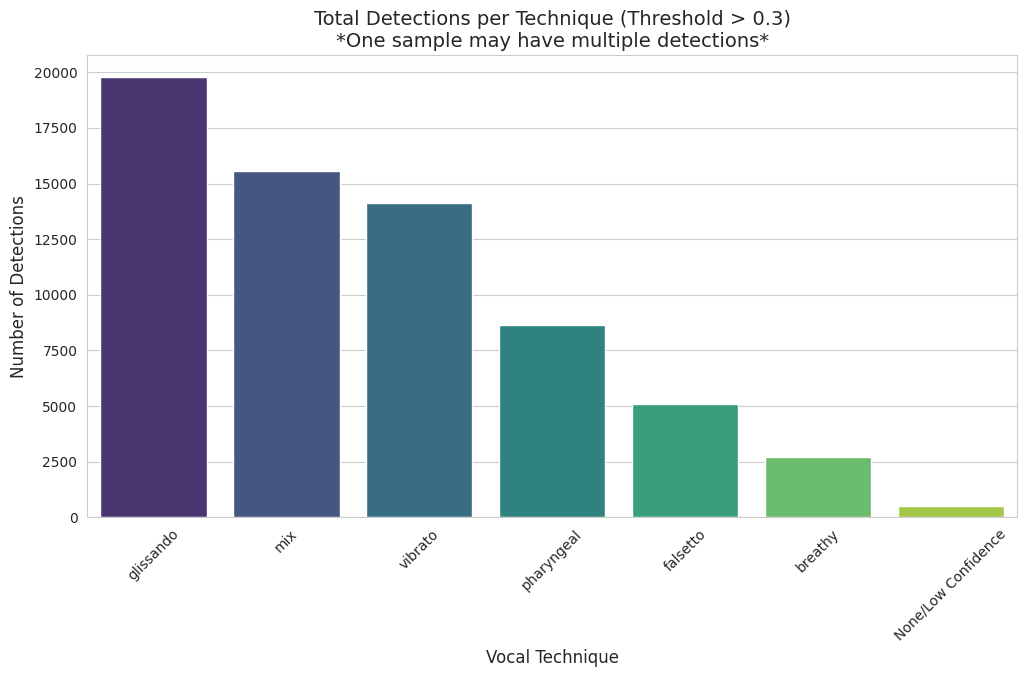

Συνολικά δείγματα: 20920
Δείγματα με πάνω από μία τεχνική (Multi-label): 15272

Αναλυτικά detections:
glissando              19776
mix                    15579
vibrato                14114
pharyngeal              8661
falsetto                5074
breathy                 2714
None/Low Confidence      497
Name: count, dtype: int64


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ονόματα κλάσεων
class_names = ['mix', 'falsetto', 'breathy', 'pharyngeal', 'glissando', 'vibrato']

# 2. Λίστα για να αποθηκεύσουμε ΟΛΕΣ τις τεχνικές που ξεπερνούν το 0.4 για κάθε δείγμα
all_detected_techniques = []

for i in range(len(predictions)):
    # Βρίσκουμε τα indices όπου το score είναι > 0.3
    detected_indices = np.where(predictions[i] > 0.3)[0]

    if len(detected_indices) > 0:
        for idx in detected_indices:
            all_detected_techniques.append(class_names[idx])
    else:
        all_detected_techniques.append('None/Low Confidence')

# 3. Οπτικοποίηση
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Καταμέτρηση εμφανίσεων
tech_series = pd.Series(all_detected_techniques)
counts = tech_series.value_counts()

# Δημιουργία barplot
sns.barplot(x=counts.index, y=counts.values, palette='viridis')

plt.title('Total Detections per Technique (Threshold > 0.3)\n*One sample may have multiple detections*', fontsize=14)
plt.xlabel('Vocal Technique', fontsize=12)
plt.ylabel('Number of Detections', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# 4. Εμφάνιση των "πολλαπλών" ανιχνεύσεων για τη διπλωματική
multi_label_samples = 0
for i in range(len(predictions)):
    if np.sum(predictions[i] > 0.4) > 1:
        multi_label_samples += 1

print(f"Συνολικά δείγματα: {len(predictions)}")
print(f"Δείγματα με πάνω από μία τεχνική (Multi-label): {multi_label_samples}")
print("\nΑναλυτικά detections:")
print(counts)

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("model_pitch_leaky (1).h5")
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ spectrogram_input   │ (None, 160, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 160, 128,  │        320 │ spectrogram_inpu… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 128,  │        128 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 80, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_6 │ (None, 80, 64,    │          0 │ max_pooling2d_6[… │
│ (SpatialDropout2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pitch_input         │ (None, 128, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 80, 64,    │     18,496 │ spatial_dropout2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 128, 32)   │        384 │ pitch_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 64,    │        256 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 32)   │        128 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 40, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 128, 64)   │      6,208 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_7 │ (None, 40, 32,    │          0 │ max_pooling2d_7[… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 128, 64)   │          0 │ conv1d_7[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ spatial_dropout2… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ spatial_dropout2… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ leaky_re_lu_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 60,040 (234.54 KB)

 Trainable params: 59,398 (232.02 KB)

 Non-trainable params: 640 (2.50 KB)

 Optimizer params: 2 (12.00 B)

In [ ]:
import numpy as np

# Ονόματα κλάσεων
class_names = ['mix', 'falsetto', 'breathy', 'pharyngeal', 'glissando', 'vibrato']

idx = 7000  # Το δείγμα που διάλεξες
mel_s = X_mel_new[idx:idx+1]
pitch_s = X_pitch_new[idx:idx+1]

# Πρόβλεψη
preds = model.predict([mel_s, pitch_s])

# Εύρεση όλων των τεχνικών πάνω από το threshold 0.4
detected_indices = np.where(preds[0] > 0.4)[0]
detected_labels = [class_names[i] for i in detected_indices]

print(f"--- Ανάλυση Δείγματος {idx} ---")
if len(detected_labels) > 0:
    print(f"Ανιχνεύθηκαν {len(detected_labels)} τεχνικές:")
    for i in detected_indices:
        confidence = preds[0][i]
        print(f"* {class_names[i].upper()}: {confidence:.2%}")
else:
    top_idx = np.argmax(preds[0])
    print(f"Καμία τεχνική > 0.4. Η επικρατέστερη ήταν: {class_names[top_idx]} ({preds[0][top_idx]:.2%})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
--- Ανάλυση Δείγματος 7000 ---
Ανιχνεύθηκαν 4 τεχνικές:
* MIX: 43.56%
* PHARYNGEAL: 42.26%
* GLISSANDO: 54.24%
* VIBRATO: 66.94%


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def get_gradcam_multi(model, mel_input, pitch_input, layer_name, class_idx):
    # Μετατροπή ονόματος σε index
    class_names = ['mix', 'falsetto', 'breathy', 'pharyngeal', 'glissando', 'vibrato']
    if isinstance(class_idx, str):
        class_idx = class_names.index(class_idx)

    # Ορίζουμε το μοντέλο με δύο outputs
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        model_outputs = grad_model([mel_input, pitch_input])
        conv_output_tensor = model_outputs[0]

        # ΕΔΩ ΕΙΝΑΙ Η ΔΙΟΡΘΩΣΗ:
        # Αν το predictions είναι λίστα, παίρνουμε το πρώτο στοιχείο [0]
        predictions_tensor = model_outputs[1]
        if isinstance(predictions_tensor, list):
            predictions_tensor = predictions_tensor[0]

        loss = predictions_tensor[:, class_idx]

    # Υπολογισμός Gradients
    grads = tape.gradient(loss, conv_output_tensor)

    # Global Average Pooling των gradients
    dims = len(grads.shape)
    weights = tf.reduce_mean(grads, axis=tuple(range(dims - 1)))

    # Δημιουργία Heatmap
    output = conv_output_tensor[0]
    cam = np.dot(output, weights)

    # ReLU και Normalization
    cam = np.maximum(cam, 0)
    if np.max(cam) > 0:
        cam = cam / np.max(cam)

    return cam

# --- ΕΚΤΕΛΕΣΗ ΓΙΑ ΕΝΑ ΔΕΙΓΜΑ ---

# 1. Grad-CAM για το Spectrogram (2D)
heatmap_mel = get_gradcam_multi(model, mel_s, pitch_s, 'conv2d_7', 5)

# 2. Grad-CAM για το Pitch (1D)
heatmap_pitch = get_gradcam_multi(model, mel_s, pitch_s, 'conv1d_7', 5)

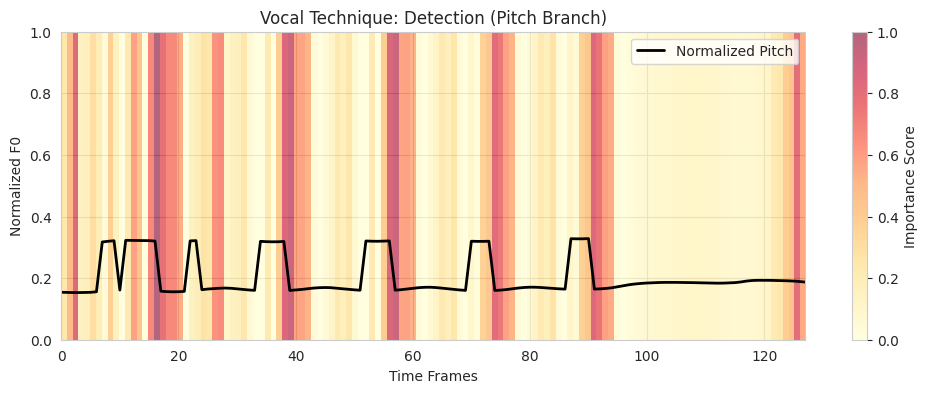

In [ ]:
def plot_gradcam_pitch(pitch_data, heatmap, title="Grad-CAM Pitch Contour"):
    plt.figure(figsize=(12, 4))

    # Σχεδιάζουμε τη γραμμή του Pitch
    x_axis = np.arange(len(pitch_data))
    plt.plot(x_axis, pitch_data[:, 0], color='black', linewidth=2, label='Normalized Pitch', zorder=2)

    # Σχεδιάζουμε το Heatmap ως background
    # Κάνουμε το heatmap 2D (1 x 128) για να το δείξει το imshow
    plt.imshow(heatmap[np.newaxis, :], aspect='auto', extent=[0, len(pitch_data)-1, 0, 1],
               cmap='YlOrRd', alpha=0.6, zorder=1)

    plt.title(title)
    plt.xlabel("Time Frames")
    plt.ylabel("Normalized F0")
    plt.legend()
    plt.colorbar(label="Importance Score")
    plt.show()

# Χρήση:
plot_gradcam_pitch(X_pitch_new[idx], heatmap_pitch, title="Vocal Technique: Detection (Pitch Branch)")

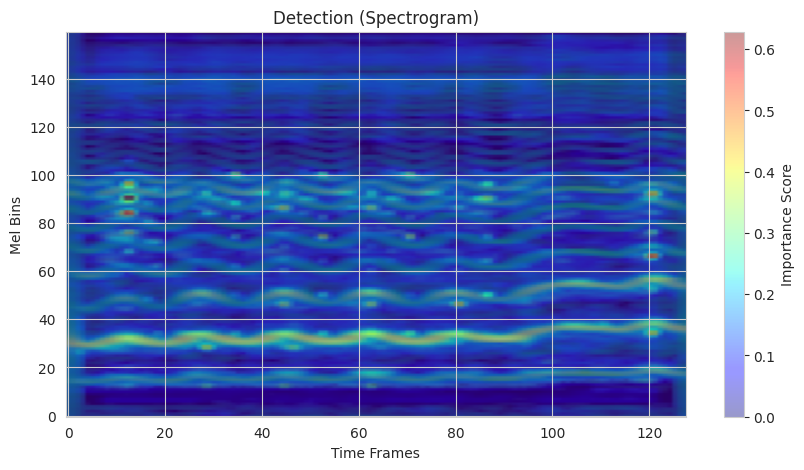

In [ ]:
import cv2

def plot_gradcam_mel(mel_data, heatmap, title="Grad-CAM Mel-Spectrogram"):
    # 1. Μετατρέπουμε το heatmap στο μέγεθος του αρχικού spectrogram (160x128)
    # Προσοχή: το mel_data έχει σχήμα (160, 128, 1)
    heatmap_resized = cv2.resize(heatmap, (mel_data.shape[1], mel_data.shape[0]))

    plt.figure(figsize=(10, 5))

    # Εμφάνιση του Spectrogram
    plt.imshow(mel_data[:, :, 0], aspect='auto', origin='lower', cmap='viridis')

    # Εμφάνιση του Heatmap από πάνω με διαφάνεια (alpha)
    # Χρησιμοποιούμε το 'jet' colormap γιατί το κόκκινο δείχνει τη μέγιστη προσοχή
    plt.imshow(heatmap_resized, aspect='auto', origin='lower', cmap='jet', alpha=0.4)

    plt.title(title)
    plt.xlabel("Time Frames")
    plt.ylabel("Mel Bins")
    plt.colorbar(label="Importance Score")
    plt.show()

# Χρήση:
plot_gradcam_mel(X_mel_new[idx], heatmap_mel, title=f"Detection (Spectrogram)")

In [ ]:
import pandas as pd
from scipy.stats import entropy
import numpy as np

tech_cols = ['vibrato', 'mix', 'falsetto', 'breathy', 'pharyngeal', 'glissando']
features_list = []

# Group by (filename)
for wav, group_raw in df_tech_features.groupby('full_path'):
    group = group_raw.copy()
    features = {'full_path': wav}

    # 1. Vocal Technique Statistics (Mean, Std, Max, Peak Factor)
    for tech in tech_cols:
        m = group[tech].mean()
        s = group[tech].std()
        mx = group[tech].max()

        features[f'{tech}_mean'] = m
        features[f'{tech}_std'] = s
        features[f'{tech}_max'] = mx
        # Peak Factor
        features[f'{tech}_peak_factor'] = mx / (m + 1e-7)

    group['dominant_tech'] = group[tech_cols].idxmax(axis=1)

    changes = (group['dominant_tech'] != group['dominant_tech'].shift()).sum() - 1
    features['num_tech_changes'] = max(0, changes)

    tech_sums = group[tech_cols].sum()
    if tech_sums.sum() > 0:
        tech_probs = tech_sums / tech_sums.sum()
        features['tech_entropy'] = entropy(tech_probs)
    else:
        features['tech_entropy'] = 0

    features_list.append(features)

df_structural_tech = pd.DataFrame(features_list)

print(f"Calculated vocal technique statistics for {len(df_structural_tech)} files.")

Calculated vocal technique statistics for 3406 files.


In [ ]:
df_final = df_features.merge(df_structural_tech, on='full_path', how='inner')

In [ ]:
df_final.to_csv('/content/drive/MyDrive/vocalsetv2_check2.csv', index=False)

In [ ]:
df_final = pd.read_csv('/content/drive/MyDrive/vocalset_check2.csv')

# Phonemes

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

def extract_phoneme_features(filename, df):
    df_wav = df[df['Filename'] == filename].copy()
    if df_wav.empty:
        return {}

    ARPABET_VOWELS = {'AA', 'AE', 'AH', 'AO', 'AW', 'AY', 'EH', 'ER', 'EY', 'IH', 'IY', 'OW', 'OY', 'UH', 'UW'}

    def is_vowel(p):
        if pd.isna(p): return False
        # Αφαιρούμε τυχόν αριθμούς (π.χ. AA1 -> AA)
        clean_p = ''.join([i for i in str(p) if not i.isdigit()])
        return clean_p in ARPABET_VOWELS

    def calc_avg_dist(temp_df):
        if len(temp_df) < 2: return 0.0
        return temp_df['Start time'].diff().mean()


    # Only phonemes ignore pauses
    speech_df = df_wav[df_wav['Phoneme'] != 'pause'].copy()
    pauses_df = df_wav[df_wav['Phoneme'] == 'pause'].copy()
    total_pauses_count = len(pauses_df)
    ap_df = pauses_df[pauses_df['is_breath'] == 'audible pause']
    sp_df = pauses_df[pauses_df['is_breath'] == 'silent pause']

    # Basic time calculations
    total_duration = df_wav['Duration'].sum()
    vocalized_duration = speech_df['Duration'].sum()

    # Handle empty speech edge case (silence-only files)
    if speech_df.empty:
      return {k: 0.0 for k in [
        "phoneme_duration_cv",
        "articulation_rate",
        "vowel_ratio",
        "consonant_ratio",
        "avg_distance_pauses",
        "ap_ratio",
        "sp_ratio",
        "mean_phoneme_duration",
        "std_phoneme_duration",
        "pause_ratio"
    ]}

    mean_dur = float(speech_df['Duration'].mean())
    std_dur = float(speech_df['Duration'].std() if len(speech_df) > 1 else 0.0)

    speech_df['is_vow'] = speech_df['Phoneme'].apply(is_vowel).copy()

    vowel_dur = speech_df[speech_df['is_vow']]['Duration'].sum()
    cons_dur = speech_df[~speech_df['is_vow']]['Duration'].sum()
    vowel_ratio = vowel_dur / vocalized_duration
    consonant_ratio = cons_dur / vocalized_duration

    if total_pauses_count > 0:
        ap_ratio = len(ap_df) / total_pauses_count
        sp_ratio = len(sp_df) / total_pauses_count
    else:
        ap_ratio = 0.0
        sp_ratio = 0.0

    avg_dist_pauses = calc_avg_dist(pauses_df)

    # Feature Collection
    features = {
        "phoneme_duration_cv": std_dur / mean_dur if mean_dur > 0 else 0.0,
        "articulation_rate": len(speech_df) / vocalized_duration if vocalized_duration > 0 else 0.0,
        "vowel_ratio": vowel_ratio,
        "consonant_ratio": consonant_ratio,
        "avg_distance_pauses": avg_dist_pauses,
        "ap_ratio": ap_ratio,
        "sp_ratio": sp_ratio,
        "mean_phoneme_duration": mean_dur,
        "std_phoneme_duration": std_dur,
        "pause_ratio": pauses_df['Duration'].sum() / total_duration if total_duration > 0 else 0.0,
    }

    # Clean any NaNs to 0.0 just in case
    return {k: (0.0 if pd.isna(v) else v) for k, v in features.items()}

In [ ]:
import pandas as pd
df_phonemes = pd.read_csv('/content/drive/MyDrive/VocalSet2/your_file_sorted.csv')

In [ ]:
df_phonemes.columns

Index(['Filename', ' Gender', ' Singer Name', ' Technique', ' Music Type',
       ' Vowel', ' BPM', ' Total Duration', ' Sequence', ' Start time',
       ' End time', ' Duration', ' Type', ' Average F0', ' Median F0',
       ' Min F0', ' Max F0', ' Standard deviation F0',
       ' Average F0 in range of STD', ' Estimated MIDI code',
       ' Ground truth Note name', ' Ground Truth Frequency',
       ' Ground Truth MIDI code', ' Lyric', ' Ground Truth Note duration name',
       ' Ground Truth note duration', ' Interval to the previous note',
       ' Interval to the following note', ' Shifted MIDI code',
       ' Estimated MIDI - Nominal MIDI', ' Shifted MIDI - Nominal MIDI',
       ' Estimated Midi Interval Difference To Previous Note',
       ' Estimated Midi Interval Difference To Following Note',
       ' Previous note type', ' Following note type', ' Repetition No'],
      dtype='object')

In [ ]:
cols_to_keep = ['Filename',
 ' Singer Name',' Technique',
 ' Vowel',
 ' Total Duration',
 ' Start time',
 ' End time', ' Duration',
 ' Type']
df_analysis = df_phonemes[cols_to_keep]

In [ ]:
df_analysis

,Filename,Singer Name,Technique,Vowel,Total Duration,Start time,End time,Duration,Type
0,f1_arpeggios_belt_c_a,f1,Belt_Harsh,a,7.27946,0.00000,0.34830,0.34830,Rest
1,m3_scales_belt_i,m3,Belt_Harsh,i,6.89633,4.20281,4.36535,0.16254,Sound
2,m3_scales_belt_i,m3,Belt_Harsh,i,6.89633,4.08671,4.17959,0.09288,Transition
3,m3_scales_belt_i,m3,Belt_Harsh,i,6.89633,3.90095,4.06349,0.16254,Sound
4,m3_scales_belt_i,m3,Belt_Harsh,i,6.89633,3.76163,3.87773,0.11610,Transition
...,...,...,...,...,...,...,...,...,...
62157,m8_scales_f_slow_forte_o,m8,NaN,o,8.47528,6.80345,6.89633,0.09288,Transition
62158,m8_scales_f_slow_forte_o,m8,NaN,o,8.47528,6.91955,7.24463,0.32508,Sound
62159,m8_scales_f_slow_forte_o,m8,NaN,o,8.47528,7.26785,7.38395,0.11610,Transition
62160,m8_scales_f_slow_forte_o,m8,NaN,o,8.47528,7.40717,8.24308,0.83591,Sound


In [ ]:
import os
import glob
import pandas as pd

df_analysis['filename'] = df_analysis['Filename'].apply(lambda x: x if x.endswith('.wav') else f"{x}.wav")

base_path = "/content/drive/MyDrive/VocalSet2/"

# 1. Recursively find all .wav files in the directory and subdirectories
all_files_in_drive = glob.glob(os.path.join(base_path, "**/*.wav"), recursive=True)

# 2. Create a dictionary mapping the base filename (e.g., 'song.wav') to its full absolute path
path_map = {os.path.basename(f): f for f in all_files_in_drive}

# 3. Map the full paths back to the DataFrame based on the normalized filename
df_analysis['full_path'] = df_analysis['filename'].map(path_map)

missing_files = df_analysis['full_path'].isna().sum()
if missing_files > 0:
    print(f"Warning: {missing_files} files were not found in Google Drive!")
else:
    print("All files matched successfully!")

print(df_analysis[['filename', 'full_path']].head())

                    filename  \
0  f1_arpeggios_belt_c_a.wav   
1       m3_scales_belt_i.wav   
2       m3_scales_belt_i.wav   
3       m3_scales_belt_i.wav   
4       m3_scales_belt_i.wav   

                                           full_path  
0  /content/drive/MyDrive/VocalSet2/belt/f1_arpeg...  
1  /content/drive/MyDrive/VocalSet2/belt/m3_scale...  
2  /content/drive/MyDrive/VocalSet2/belt/m3_scale...  
3  /content/drive/MyDrive/VocalSet2/belt/m3_scale...  
4  /content/drive/MyDrive/VocalSet2/belt/m3_scale...  


/tmp/ipykernel_2847/475199991.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analysis['filename'] = df_analysis['Filename'].apply(lambda x: x if x.endswith('.wav') else f"{x}.wav")
/tmp/ipykernel_2847/475199991.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analysis['full_path'] = df_analysis['filename'].map(path_map)


In [ ]:
df_analysis.columns

Index(['Filename', ' Singer Name', ' Technique', ' Vowel', ' Total Duration',
       ' Start time', ' End time', ' Duration', ' Type', 'filename',
       'full_path'],
      dtype='object')

In [ ]:
df_analysis[' Vowel'].value_counts()

,count
Vowel,
o,14110
u,11189
e,10820
a,10795
i,10711


In [ ]:
import pandas as pd
import numpy as np

def extract_phoneme_features(wave_file_path, df_phonemes):
    """
    wave_file_path: the full path of the file
    df_phonemes: df containing phoneme alignment
    """
    df_wav = df_phonemes[df_phonemes['full_path'] == wave_file_path].copy()

    if df_wav.empty:
        return {f: 0.0 for f in [
            'articulation_rate', 'std_phoneme_duration', 'phoneme_duration_cv',
            'pause_ratio', 'mean_phoneme_duration', 'vowel_ratio', 'consonant_ratio',
            'mean_pause_dur', 'std_pause_dur'
        ]}

    # In VocalSet we have phoneme_type either Rest or Transition/Sound
    speech_df = df_wav[df_wav[' Type'] != 'Rest']
    pause_df = df_wav[df_wav[' Type'] == 'Rest']

    total_duration = df_wav[' Duration'].sum()
    vocalized_duration = speech_df[' Duration'].sum()

    mean_dur = float(speech_df[' Duration'].mean()) if not speech_df.empty else 0.0
    std_dur = float(speech_df[' Duration'].std()) if len(speech_df) > 1 else 0.0

    mean_pause_dur = float(pause_df[' Duration'].mean()) if not pause_df.empty else 0.0
    std_pause_dur = float(pause_df[' Duration'].std()) if len(pause_df) > 1 else 0.0

    features = {
        "articulation_rate": len(speech_df) / vocalized_duration if vocalized_duration > 0 else 0.0,
        "mean_phoneme_duration": mean_dur,
        "std_phoneme_duration": std_dur,
        "phoneme_duration_cv": std_dur / mean_dur if mean_dur > 0 else 0.0,
        "pause_ratio": pause_df[' Duration'].sum() / total_duration if total_duration > 0 else 0.0,
        "mean_pause_dur": mean_pause_dur,
        "std_pause_dur": std_pause_dur,
        "vowel_ratio": 1.0,
        "consonant_ratio": 0.0
    }

    return features

all_paths = df_analysis['full_path'].unique()
vocal_features_list = [extract_phoneme_features(f, df_analysis) for f in all_paths]

df_phoneme_final = pd.DataFrame(vocal_features_list)
df_phoneme_final.insert(0, 'full_path', all_paths)


In [ ]:
df_vocalset = df_final.merge(df_phoneme_final, on='full_path', how='inner')

In [ ]:
df_vocalset.to_csv('/content/drive/MyDrive/vocalset_check3.csv', index=False)

In [ ]:
df_phoneme_final.columns.to_list()

['full_path',
 'articulation_rate',
 'mean_phoneme_duration',
 'std_phoneme_duration',
 'phoneme_duration_cv',
 'pause_ratio',
 'mean_pause_dur',
 'std_pause_dur',
 'vowel_ratio',
 'consonant_ratio']

In [ ]:
import re
from tqdm import tqdm
import pandas as pd
import os
import numpy as np

all_features = []

# Assuming df_vocalset is already loaded and contains the 'full_path' column
# We iterate directly over the values in that column
for wave_file in tqdm(df_phoneme_final['full_path'], desc="Processing files"):

    if not isinstance(wave_file, str) or not os.path.exists(wave_file):
        continue

    filename = os.path.basename(wave_file)

    # Extract speaker id (e.g. f1, f10, m2, m11)
    match = re.search(r'^([fm]\d{1,2})', filename.lower())
    if not match:
        continue

    speaker_id = match.group(1)

    # Extract technique from the parent directory name
    technique = os.path.basename(os.path.dirname(wave_file))

    # Combine metadata with extracted features
    combined_features = {
        "speaker_id": speaker_id,
        "technique": technique,
        "full_path": wave_file,
    }

    all_features.append(combined_features)

df_features = pd.DataFrame(all_features)

print(f"\nProcessing complete! {len(df_features)} samples created.")

Processing files: 100%|██████████| 2581/2581 [00:00<00:00, 5319.31it/s]


Processing complete! 2580 samples created.


In [ ]:
df_features

,speaker_id,technique,full_path
0,f1,belt,/content/drive/MyDrive/VocalSet2/belt/f1_arpeg...
1,m3,belt,/content/drive/MyDrive/VocalSet2/belt/m3_scale...
2,m3,belt,/content/drive/MyDrive/VocalSet2/belt/m3_scale...
3,m3,belt,/content/drive/MyDrive/VocalSet2/belt/m3_scale...
4,m3,belt,/content/drive/MyDrive/VocalSet2/belt/m3_scale...
...,...,...,...
2575,f5,breathy,/content/drive/MyDrive/VocalSet2/breathy/f5_ar...
2576,f7,breathy,/content/drive/MyDrive/VocalSet2/breathy/f7_ar...
2577,f7,breathy,/content/drive/MyDrive/VocalSet2/breathy/f7_ar...
2578,f6,breathy,/content/drive/MyDrive/VocalSet2/breathy/f6_ar...


In [ ]:
df_phon = df_phoneme_final.merge(df_features, on='full_path', how='left')

In [ ]:
df_phon.columns

Index(['full_path', 'articulation_rate', 'mean_phoneme_duration',
       'std_phoneme_duration', 'phoneme_duration_cv', 'pause_ratio',
       'mean_pause_dur', 'std_pause_dur', 'vowel_ratio', 'consonant_ratio',
       'speaker_id', 'technique'],
      dtype='object')

In [ ]:
exclude_cols = ['filename', 'speaker_id', 'technique', 'full_path']
feature_cols = [c for c in df_phon.columns if c not in exclude_cols and df_phon[c].dtype in ['float64', 'int64']]

def z_speaker_normalization(df, group_col, cols_to_norm):
    df_norm = df.copy()

    means = df_norm.groupby(group_col)[cols_to_norm].transform('mean')
    stds = df_norm.groupby(group_col)[cols_to_norm].transform('std')

    df_norm[cols_to_norm] = (df_norm[cols_to_norm] - means) / (stds + 1e-9)

    return df_norm

df_normalized = z_speaker_normalization(df_phon, group_col='speaker_id', cols_to_norm=feature_cols)

In [ ]:
df_normalized.to_csv('/content/drive/MyDrive/vocalset_phon_new.csv', index=False)

# z-speaker normalization

In [ ]:
exclude_cols = ['filename', 'speaker_id', 'technique', 'full_path']
feature_cols = [c for c in df_vocalset.columns if c not in exclude_cols and df_vocalset[c].dtype in ['float64', 'int64']]

def z_speaker_normalization(df, group_col, cols_to_norm):
    df_norm = df.copy()

    means = df_norm.groupby(group_col)[cols_to_norm].transform('mean')
    stds = df_norm.groupby(group_col)[cols_to_norm].transform('std')

    df_norm[cols_to_norm] = (df_norm[cols_to_norm] - means) / (stds + 1e-9)

    return df_norm

df_normalized = z_speaker_normalization(df_vocalset, group_col='speaker_id', cols_to_norm=feature_cols)

In [ ]:
df_normalized.to_csv('/content/drive/MyDrive/vocalset_normv3_check5.csv', index=False)

# italian subset

In [ ]:
import os
import json
import pandas as pd
from tqdm import tqdm

def extract_phoneme_rows(json_path, meta):
    try:
        with open(json_path, 'r', encoding="utf-8", errors="ignore") as f:
            content = f.read().strip()
            if not content:
                return []  # empty file
            data = json.loads(content)
    except json.JSONDecodeError:
        return []  # corrupted JSON
    except Exception as e:
        print("SKIP:", json_path, e)
        return []

    rows = []

    for item in data:
        base_info = {
            "word": item.get("word"),
            "word_start": item.get("start_time"),
            "word_end": item.get("end_time"),
            "emotion": item.get("emotion"),
            "pace": item.get("pace"),
            "range_label": item.get("range"),
            "singing_method": item.get("singing_method"),
        }

        # Only add metadata fields that are NOT None
        for k, v in meta.items():
            if v is not None:
                base_info[k] = v

        ph_list = item.get("ph", [])
        n = len(ph_list)

        ph_start = item.get("ph_start", [None] * n)
        ph_end   = item.get("ph_end",   [None] * n)

        mix_list         = item.get("mix",         ["0"] * n)
        falsetto_list    = item.get("falsetto",    ["0"] * n)
        breathy_list     = item.get("breathy",     ["0"] * n)
        pharyngeal_list  = item.get("pharyngeal",  ["0"] * n)
        glissando_list   = item.get("glissando",   ["0"] * n)
        vibrato_list     = item.get("vibrato",     ["0"] * n)

        notes = item.get("note", [])
        note_val = notes[0] if notes else None

        for i, ph in enumerate(ph_list):
            st = ph_start[i]
            en = ph_end[i]
            dur = (en - st) if st is not None and en is not None else None

            row = base_info.copy()
            row.update({
                "phoneme": ph,
                "ph_start": st,
                "ph_end": en,
                "duration": dur,
                "note": note_val,
                "mix": mix_list[i],
                "falsetto": falsetto_list[i],
                "breathy": breathy_list[i],
                "pharyngeal": pharyngeal_list[i],
                "glissando": glissando_list[i],
                "vibrato": vibrato_list[i],
            })

            rows.append(row)

    return rows


def load_gtsinger(root_folder):

    all_rows = []

    json_paths = []
    for root, _, files in os.walk(root_folder):
        for f in files:
            if f.endswith(".json"):
                json_paths.append(os.path.join(root, f))

    for json_path in tqdm(json_paths, desc="Loading JSONs"):
        parts = json_path.replace(root_folder, "").strip(os.sep).split(os.sep)

        # expected: EN-Alto-1 / Technique / SongTitle / Group / file.json
        try:
            lang_range      = parts[0]
            technique       = parts[1]
            song_title      = parts[2]
            group_folder    = parts[3]
            file_name       = parts[4]
        except IndexError:
            print("BAD PATH:", parts)
            continue

        language = lang_range.split("-")[0]
        range_folder = "-".join(lang_range.split("-")[1:])

        meta = {
            "language": language,
            "range_folder": range_folder,
            "technique_folder": technique,
            "song_title": song_title,
            "group_folder": group_folder,
            "json_file": file_name,
        }

        rows = extract_phoneme_rows(json_path, meta)
        all_rows.extend(rows)

    return pd.DataFrame(all_rows)


In [ ]:
df_phonemes_it = load_gtsinger("/content/GTSinger/Italian/Italian")

Loading JSONs: 100%|██████████| 2647/2647 [00:01<00:00, 2593.39it/s]


In [ ]:
df_phonemes_it['wav_path'] = (
    "/content/GTSinger/Italian/Italian/IT-" +
    df_phonemes_it['range_folder'].astype(str) + "/" +
    df_phonemes_it['technique_folder'].astype(str) + "/" +
    df_phonemes_it['song_title'].astype(str) + "/" +
    df_phonemes_it['group_folder'].astype(str) + "/" +
    df_phonemes_it['json_file'].str.replace(".json", ".wav")
)


In [ ]:
def extract_word_rows(json_path, meta):
    with open(json_path, 'r') as f:
        data = json.load(f)

    rows = []

    for item in data:
        base_info = {
            "word": item.get("word"),
            "word_start": item.get("start_time"),
            "word_end": item.get("end_time"),
            "emotion": item.get("emotion"),
            "pace": item.get("pace"),
            "range_label": item.get("range"),
            "singing_method": item.get("singing_method"),
            "json_path": json_path
        }

        base_info.update(meta)
        rows.append(base_info)

    return rows

def load_gtsinger_words(root_folder):

    all_rows = []

    json_paths = []
    for root, _, files in os.walk(root_folder):
        for f in files:
            if f.endswith(".json"):
                json_paths.append(os.path.join(root, f))

    for json_path in tqdm(json_paths, desc="Loading JSONs"):
        parts = json_path.replace(root_folder, "").strip(os.sep).split(os.sep)

        try:
            lang_range      = parts[0]
            technique       = parts[1]
            song_title      = parts[2]
            group_folder    = parts[3]
            file_name       = parts[4]
        except IndexError:
            print("BAD PATH:", parts)
            continue

        language = lang_range.split("-")[0]
        range_folder = "-".join(lang_range.split("-")[1:])

        meta = {
            "language": language,
            "range_folder": range_folder,
            "technique_folder": technique,
            "song_title": song_title,
            "group_folder": group_folder,
            "json_file": file_name,
        }

        rows = extract_word_rows(json_path, meta)
        all_rows.extend(rows)

    return pd.DataFrame(all_rows)


In [ ]:
df_words_it = load_gtsinger_words("/content/GTSinger/Italian/Italian")

Loading JSONs: 100%|██████████| 2647/2647 [00:00<00:00, 6636.70it/s]


In [ ]:
# 1. Βάζουμε wav_path
df_words_it["wav_path"] = df_words_it["json_path"].str.replace(".json", ".wav")

# 2. Global labels per wav_path (keep the first row)
df_labels = df_words_it.groupby("wav_path").first()[[
    "emotion",
    "pace",
    "range_label",
    "singing_method",
    "language",
    "range_folder",
    "technique_folder",
    "song_title",
    "group_folder",
    "json_file"
]].reset_index()

# 3. Lyrics aggregation (όλα τα words ενωμένα)
df_lyrics = (
    df_words_it
    .groupby("wav_path")["word"]
    .apply(lambda w: " ".join(w.dropna().tolist()))
    .reset_index()
    .rename(columns={"word": "lyrics"})
)

# 4. Merge labels + lyrics -> df_segments
df_segments_it = df_labels.merge(df_lyrics, on="wav_path")


In [ ]:
df_segments_it.shape

(1842, 12)

In [ ]:
df_segments_it.emotion.value_counts()

,count
emotion,
sad,973
happy,869


In [ ]:
df_segments_it = df_segments_it[df_segments_it['group_folder'] != 'Paired_Speech_Group']

In [ ]:
df_phonemes_it = df_phonemes_it[df_phonemes_it['group_folder'] != 'Paired_Speech_Group']

# gtsinger


In [ ]:
!gdown --folder "https://drive.google.com/drive/folders/1xcdvCxNAEEfJElt7sEP-xT8dMKxn1_Lz?usp=drive_link"

Retrieving folder contents
Processing file 1ZuY8Bj0djxK0gQHnX9ur5anUgDusZ8xp Chinese.zip
Processing file 14YYGOxyIjjR-oQ5gUbZnDRgW1mPsA3Ow dataset_license.md
Processing file 1DK1vnTs_d9JD7Xya4U5CEaXszIWyboFv English.zip
Processing file 1c-wf0Sx_BYWlW7uDSvUZt6S9-2bdmd2A French.zip
Processing file 18G4ByGGD0vV8dunDZ1NrQKubqPLuD-Jq German.zip
Processing file 1fxKD95WKbBRtLC0bTF8YcnfwHTRYJRuJ Italian.zip
Processing file 1wu4ccoht3-Yb_UIGgDGhPG-6T8cwFd70 Japanese.zip
Processing file 1hwROisMOpUEAI5d9RgHi_V5fuW59UB4u Korean.zip
Processing file 1tWaYIZLrquG_y2Nwycex4CV1a8SfqJpo processed.zip
Processing file 12_bcpmL4NGWy6bZz-e8nrvV2_MbQCise Russian.zip
Processing file 1MYGtSwSMXjkQ_93ZeQZ5Z2VJ5NX7WNu2 Spanish.zip
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1ZuY8Bj0djxK0gQHnX9ur5anUgDusZ8xp
From (redirected): https://drive.google.com/uc?id=1ZuY8Bj0djxK0gQHnX9ur5anUgDusZ8x

In [ ]:
!unzip "/content/GTSinger/Italian.zip" -d "/content/GTSinger/Italian"

Η έξοδος ροής περικόπηκε στις τελευταίες 5000 γραμμές.
  inflating: /content/GTSinger/Italian/Italian/IT-Bass-1/Mixed_Voice_and_Falsetto/Non ti amo più/Mixed_Voice_Group/0012_TextGrid  
  inflating: /content/GTSinger/Italian/Italian/IT-Bass-1/Mixed_Voice_and_Falsetto/Non ti amo più/Mixed_Voice_Group/0012.wav  
  inflating: /content/GTSinger/Italian/Italian/IT-Bass-1/Mixed_Voice_and_Falsetto/Non ti amo più/Mixed_Voice_Group/0006.wav  
  inflating: /content/GTSinger/Italian/Italian/IT-Bass-1/Mixed_Voice_and_Falsetto/Non ti amo più/Mixed_Voice_Group/0002.wav  
  inflating: /content/GTSinger/Italian/Italian/IT-Bass-1/Mixed_Voice_and_Falsetto/Non ti amo più/Mixed_Voice_Group/0004.json  
  inflating: /content/GTSinger/Italian/Italian/IT-Bass-1/Mixed_Voice_and_Falsetto/Non ti amo più/Mixed_Voice_Group/0003.wav  
  inflating: /content/GTSinger/Italian/Italian/IT-Bass-1/Mixed_Voice_and_Falsetto/Non ti amo più/Mixed_Voice_Group/0012.json  
  inflating: /content/GTSinger/Italian/Italian/IT

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df_phonemes = pd.read_csv('/content/drive/MyDrive/df_phonemes_all.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_phonemes.columns.to_list()

['Unnamed: 0',
 'word',
 'word_start',
 'word_end',
 'emotion',
 'pace',
 'range_label',
 'singing_method',
 'language',
 'range_folder',
 'technique_folder',
 'song_title',
 'group_folder',
 'json_file',
 'phoneme',
 'ph_start',
 'ph_end',
 'duration',
 'note',
 'mix',
 'falsetto',
 'breathy',
 'pharyngeal',
 'glissando',
 'vibrato',
 'phoneme_type',
 'stress',
 'wav_path']

In [ ]:

df_filtered = df_phonemes[df_phonemes['language'] != 'ZH']
df_filtered.shape

(420436, 28)

In [ ]:
df_segments = pd.read_csv('/content/drive/MyDrive/df_segments_all.csv')

In [ ]:
df_segments = df_segments[df_segments['language'] != 'ZH']


In [ ]:
df_segments.shape

(10657, 39)

In [ ]:
# Calculate raw counts per emotion per singer
emotion_counts = df_segments.groupby(['unique_singer_id', 'emotion']).size().unstack(fill_value=0)

print(emotion_counts)

emotion           happy   sad
unique_singer_id             
DE_Soprano-1        666  1058
DE_Tenor-1         1143   531
EN_Alto-1           525   727
EN_Alto-2           579  1124
EN_Tenor-1          710  1056
FR_Soprano-1        900   323
FR_Tenor-1          990   325


# technique

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import entropy
from tqdm import tqdm

tech_cols = ['vibrato', 'mix', 'falsetto', 'breathy', 'pharyngeal', 'glissando']

for col in tech_cols:
    df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce').fillna(0)

df_filtered['duration'] = pd.to_numeric(df_filtered['duration'], errors='coerce').fillna(0)

features_list = []

grouped = df_filtered.groupby('wav_path')

for wav, group_raw in tqdm(grouped, desc="Extracting Technique Features"):
    group = group_raw.copy()
    features = {'wav_path': wav}

    # Duration of the clip
    total_dur = group['duration'].sum()

    for tech in tech_cols:
        # Weighted Mean: What is the duration (percentage) of the technique's presence in the total time?
        if total_dur > 0:
            w_mean = (group[tech] * group['duration']).sum() / total_dur
        else:
            w_mean = 0

        # Note: The std is calculated on the binary values per phoneme
        w_std = group[tech].std() if len(group) > 1 else 0
        w_max = group[tech].max()

        # Peak Factor: Max / Weighted Mean
        w_pf = w_max / w_mean if w_mean > 0 else 0

        features[f'{tech}_mean'] = w_mean
        features[f'{tech}_std'] = w_std
        features[f'{tech}_max'] = w_max
        features[f'{tech}_peak_factor'] = w_pf

    # Create the techniques matrix (phonemes x techniques)
    tech_matrix = group[tech_cols].values
    # Count how many times the state changes (any of the 6 techniques)
    # from one phoneme to the next
    if len(tech_matrix) > 1:
        changes = (np.diff(tech_matrix, axis=0) != 0).any(axis=1).sum()
    else:
        changes = 0
    features['num_tech_changes'] = int(changes)

    # Use the total duration of each technique for the distribution
    tech_durations = [(group[t] * group['duration']).sum() for t in tech_cols]
    sum_all_tech_durs = sum(tech_durations)

    if sum_all_tech_durs > 0:
       # Probability of each technique's occurrence based on time
        probs = [d / sum_all_tech_durs for d in tech_durations]
        features['tech_entropy'] = entropy(probs)
    else:
        features['tech_entropy'] = 0

    features_list.append(features)

df_technique_features = pd.DataFrame(features_list)

df_technique_features = df_technique_features.fillna(0)

print(f"Features extracted for {len(df_technique_features)} audio files.")
print(df_technique_features.head())

/tmp/ipykernel_7477/3798086065.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce').fillna(0)
/tmp/ipykernel_7477/3798086065.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['duration'] = pd.to_numeric(df_filtered['duration'], errors='coerce').fillna(0)
Extracting Technique Features: 100%|██████████| 10781/10781 [00:36<00:00, 293.92it/s]


Features extracted for 10781 audio files.
                                            wav_path  vibrato_mean  \
0  /content/GTSinger/English/English/EN-Alto-1/Br...           0.0   
1  /content/GTSinger/English/English/EN-Alto-1/Br...           0.0   
2  /content/GTSinger/English/English/EN-Alto-1/Br...           0.0   
3  /content/GTSinger/English/English/EN-Alto-1/Br...           0.0   
4  /content/GTSinger/English/English/EN-Alto-1/Br...           0.0   

   vibrato_std  vibrato_max  vibrato_peak_factor  mix_mean   mix_std  mix_max  \
0          0.0            0                  0.0  0.748429  0.331662        1   
1          0.0            0                  0.0  0.837806  0.254972        1   
2          0.0            0                  0.0  0.822219  0.294245        1   
3          0.0            0                  0.0  0.796796  0.358569        1   
4          0.0            0                  0.0  0.423830  0.503761        1   

   mix_peak_factor  falsetto_mean  ...  pharyngeal

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import entropy
from tqdm import tqdm

tech_cols = ['vibrato', 'mix', 'falsetto', 'breathy', 'pharyngeal', 'glissando']

for col in tech_cols:
    df_phonemes_it[col] = pd.to_numeric(df_phonemes_it[col], errors='coerce').fillna(0)

df_phonemes_it['duration'] = pd.to_numeric(df_phonemes_it['duration'], errors='coerce').fillna(0)

features_list = []

grouped = df_phonemes_it.groupby('wav_path')

for wav, group_raw in tqdm(grouped, desc="Extracting Technique Features"):
    group = group_raw.copy()
    features = {'wav_path': wav}

    # Duration of the clip
    total_dur = group['duration'].sum()

    for tech in tech_cols:
        # Weighted Mean: What is the duration (percentage) of the technique's presence in the total time?
        if total_dur > 0:
            w_mean = (group[tech] * group['duration']).sum() / total_dur
        else:
            w_mean = 0

        # Note: The std is calculated on the binary values per phoneme
        w_std = group[tech].std() if len(group) > 1 else 0
        w_max = group[tech].max()

        # Peak Factor: Max / Weighted Mean
        w_pf = w_max / w_mean if w_mean > 0 else 0

        features[f'{tech}_mean'] = w_mean
        features[f'{tech}_std'] = w_std
        features[f'{tech}_max'] = w_max
        features[f'{tech}_peak_factor'] = w_pf

    # Create the techniques matrix (phonemes x techniques)
    tech_matrix = group[tech_cols].values
    # Count how many times the state changes (any of the 6 techniques)
    # from one phoneme to the next
    if len(tech_matrix) > 1:
        changes = (np.diff(tech_matrix, axis=0) != 0).any(axis=1).sum()
    else:
        changes = 0
    features['num_tech_changes'] = int(changes)

    # Use the total duration of each technique for the distribution
    tech_durations = [(group[t] * group['duration']).sum() for t in tech_cols]
    sum_all_tech_durs = sum(tech_durations)

    if sum_all_tech_durs > 0:
       # Probability of each technique's occurrence based on time
        probs = [d / sum_all_tech_durs for d in tech_durations]
        features['tech_entropy'] = entropy(probs)
    else:
        features['tech_entropy'] = 0

    features_list.append(features)

df_technique_features = pd.DataFrame(features_list)

df_technique_features = df_technique_features.fillna(0)

print(f"Features extracted for {len(df_technique_features)} audio files.")
print(df_technique_features.head())

/tmp/ipykernel_641/726406026.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_phonemes_it[col] = pd.to_numeric(df_phonemes_it[col], errors='coerce').fillna(0)
/tmp/ipykernel_641/726406026.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_phonemes_it['duration'] = pd.to_numeric(df_phonemes_it['duration'], errors='coerce').fillna(0)
Extracting Technique Features: 100%|██████████| 1842/1842 [00:05<00:00, 334.94it/s]

Features extracted for 1842 audio files.
                                            wav_path  vibrato_mean  \
0  /content/GTSinger/Italian/Italian/IT-Bass-1/Br...           0.0   
1  /content/GTSinger/Italian/Italian/IT-Bass-1/Br...           0.0   
2  /content/GTSinger/Italian/Italian/IT-Bass-1/Br...           0.0   
3  /content/GTSinger/Italian/Italian/IT-Bass-1/Br...           0.0   
4  /content/GTSinger/Italian/Italian/IT-Bass-1/Br...           0.0   

   vibrato_std  vibrato_max  vibrato_peak_factor  mix_mean   mix_std  mix_max  \
0          0.0            0                  0.0  0.913770  0.213083        1   
1          0.0            0                  0.0  0.785300  0.323381        1   
2          0.0            0                  0.0  0.877783  0.271746        1   
3          0.0            0                  0.0  0.757184  0.288104        1   
4          0.0            0                  0.0  0.830508  0.232311        1   

   mix_peak_factor  falsetto_mean  ...  pharyngeal_

# phonemes

In [ ]:
df_filtered.columns

Index(['Unnamed: 0', 'word', 'word_start', 'word_end', 'emotion', 'pace',
       'range_label', 'singing_method', 'language', 'range_folder',
       'technique_folder', 'song_title', 'group_folder', 'json_file',
       'phoneme', 'ph_start', 'ph_end', 'duration', 'note', 'mix', 'falsetto',
       'breathy', 'pharyngeal', 'glissando', 'vibrato', 'phoneme_type',
       'stress', 'wav_path'],
      dtype='object')

In [ ]:
unique_phonemes = df_filtered[df_filtered['language'] == 'EN']['phoneme'].unique()
print(unique_phonemes)

['OW1' 'DH' 'AH0' 'R' 'IY1' 'Z' 'N' 'AY1' 'HH' 'L' 'D' 'AA1' '<SP>' 'AW1'
 'ER0' 'W' 'G' 'TH' 'UW1' 'M' 'AE1' 'IH1' 'IY0' 'EH1' 'S' 'SH' 'AH1' 'IH0'
 'NG' 'T' 'Y' 'F' 'K' 'EY1' 'V' 'CH' '<AP>' 'B' 'AO1' 'UH1' 'P' 'UH0'
 'EY2' 'ER1' 'UH2' 'AE2' 'JH' 'EH2' 'AH2' 'EH0' 'IH2' 'AO0' 'AY2' 'AO2'
 'OY1' 'OW0' 'AY0' 'OW2' 'EY0' 'UW0' 'IY2' 'ZH' 'AA2' 'ER2' 'AW2' 'AE0'
 'UW2']


In [ ]:
unique_phonemes = df_filtered[df_filtered['language'] == 'FR']['phoneme'].unique()
print(unique_phonemes)

['e' 'ʒ' 'ə' 't' 'ɛ' 'y' 'n' 'ʃ' 'ɔ' 'z' 'a' 'w' '<AP>' 'k' 'ʁ' 'm' '<SP>'
 'v' 'p' 'ɛ̃' 'ɡ' 's' 'u' 'ɑ̃' 'd' 'ɔ̃' 'o' 'l' 'œ' 'i' 'ʎ' 'b' 'ɑ' 'j'
 'f' 'ɲ' 'c' 'ø' 'ɥ' 'mʲ' 'ŋ' 'tʃ' 'ɟ']


In [ ]:
unique_phonemes = df_filtered[df_filtered['language'] == 'DE']['phoneme'].unique()
print(unique_phonemes)

['ʃ' 'p' 'ɪ' 'ts' 'ə' 'n' 't' 'aj' '<AP>' 'd' 'eː' 'aː' 'm' 'ɐ' 'l' 'iː'
 's' 'h' 'a' 'ʁ' 'tʰ' 'uː' 'ç' 'z' 'oː' 'ʊ' 'ɛ' '<SP>' 'v' 'f' 'k' 'b' 'ɡ'
 'ɔ' 'ɟ' 'kʰ' 'yː' 'aw' 'ŋ' 'x' 'n̩' 'ʏ' 'œ' 'øː' 'm̩' 'j' 'ɔʏ' 'pʰ' 'pf'
 'tʃ' 'cʰ' 'ɲ']


In [ ]:
import pandas as pd
import re

def extract_phoneme_features(filename, df):
    df_wav = df[df['wav_path'] == filename].copy()

    if df_wav.empty:
        return {}

    def calc_avg_dist(temp_df):
        if len(temp_df) < 2: return 0.0
        return temp_df['ph_start'].diff().mean()

    language = df_wav['language'].iloc[0]

    vowel_maps = {
        'EN': r'^(AA|AE|AH|AO|AW|AY|EH|ER|EY|IH|IY|OW|OY|UH|UW)\d?$',
        'FR': {'e', 'ə', 'ɛ', 'y', 'ɔ', 'a', 'ɛ̃', 'u', 'ɑ̃', 'ɔ̃', 'o', 'œ', 'i', 'ɑ', 'ø'},
        'DE': {'ɪ', 'ə', 'aj', 'eː', 'aː', 'ɐ', 'iː', 'a', 'uː', 'oː', 'ʊ', 'ɛ', 'ɔ', 'yː', 'aw', 'ʏ', 'œ', 'øː', 'ɔʏ'}
    }
    # Is_Pause column based on phoneme_type column
    df_wav['Is_Pause'] = df_wav['phoneme'].isin(['<AP>', '<SP>']).astype(int)    # Subset of phonemes (speech)
    speech_df = df_wav[df_wav['Is_Pause'] == 0].copy()
    pause_df = df_wav[df_wav['Is_Pause'] == 1].copy()

    if speech_df.empty:
        return {k: 0.0 for k in ["phoneme_duration_cv", "articulation_rate", 'mean_pause_duration', 'std_pause_duration',
                                 "mean_phoneme_duration", "std_phoneme_duration", "pause_ratio", "vowel_ratio", "avg_distance_pauses"]}

    if language == 'EN':
        # Στα αγγλικά χρησιμοποιούμε regex γιατί έχουν αριθμούς τόνου (π.χ. IH1, AH0)
        speech_df['is_vowel'] = speech_df['phoneme'].str.match(vowel_maps['EN'])
    else:
        # Στις άλλες γλώσσες ελέγχουμε αν το phoneme υπάρχει στο set
        current_vowels = vowel_maps.get(language, set())
        speech_df['is_vowel'] = speech_df['phoneme'].isin(current_vowels)


    mean_dur = float(speech_df['duration'].mean())
    std_dur = float(speech_df['duration'].std() if len(speech_df) > 1 else 0.0)
    total_time = df_wav['ph_end'].max() - df_wav['ph_start'].min()
    total_duration = df_wav['duration'].sum()
    vocalized_duration = speech_df['duration'].sum()
    vowel_dur = speech_df[speech_df['is_vowel'] == True]['duration'].sum()

    if not pause_df.empty:
        mean_pause_dur = float(pause_df['duration'].mean())
        std_pause_dur = float(pause_df['duration'].std()) if len(pause_df) > 1 else 0.0
        avg_dist_pauses = calc_avg_dist(pause_df)
    else:
        mean_pause_dur = std_pause_dur = avg_dist_pauses = 0.0

    features = {
        "rel_mean_phoneme_duration": mean_dur / total_time if total_time > 0 else 0.0,
        "phoneme_duration_cv": std_dur / mean_dur if mean_dur > 0 else 0.0,
        "mean_pause_duration": mean_pause_dur,
        "std_pause_duration": std_pause_dur,
        "articulation_rate": len(speech_df) / vocalized_duration if vocalized_duration > 0 else 0.0,
        "mean_phoneme_duration": mean_dur,
        "std_phoneme_duration": std_dur,
        "avg_distance_pauses": avg_dist_pauses,
        "vowel_ratio": vowel_dur / vocalized_duration if vocalized_duration > 0 else 0.0,
        "pause_ratio": (total_duration - vocalized_duration) / total_duration if total_duration > 0 else 0.0,
    }

    return features

In [ ]:
import pandas as pd
from tqdm import tqdm

unique_wavs = df_filtered['wav_path'].unique()

phoneme_feats_list = []

for wav_path in tqdm(unique_wavs, desc='Computing detailed phoneme features...'):

    features = extract_phoneme_features(wav_path, df_filtered)

    if features:
        features['wav_path'] = wav_path
        phoneme_feats_list.append(features)

df_phoneme_feats = pd.DataFrame(phoneme_feats_list)

print(df_phoneme_feats[['wav_path', 'phoneme_duration_cv', 'articulation_rate']].head())

Computing detailed phoneme features...: 100%|██████████| 10781/10781 [07:06<00:00, 25.29it/s]

                                            wav_path  phoneme_duration_cv  \
0  /content/GTSinger/English/English/EN-Tenor-1/V...             1.712458   
1  /content/GTSinger/English/English/EN-Tenor-1/V...             2.386814   
2  /content/GTSinger/English/English/EN-Tenor-1/V...             2.447377   
3  /content/GTSinger/English/English/EN-Tenor-1/V...             2.092867   
4  /content/GTSinger/English/English/EN-Tenor-1/V...             1.984574   

   articulation_rate  
0           1.876407  
1           3.499125  
2           3.570549  
3           3.018542  
4           3.522081  


In [ ]:
import pandas as pd
from tqdm import tqdm

unique_wavs = df_phonemes_it['wav_path'].unique()

phoneme_feats_list = []

for wav_path in tqdm(unique_wavs, desc='Computing detailed phoneme features...'):

    features = extract_phoneme_features(wav_path, df_phonemes_it)

    if features:
        features['wav_path'] = wav_path
        phoneme_feats_list.append(features)

df_phoneme_feats = pd.DataFrame(phoneme_feats_list)

print(df_phoneme_feats[['wav_path', 'phoneme_duration_cv', 'articulation_rate']].head())

Computing detailed phoneme features...: 100%|██████████| 1842/1842 [00:16<00:00, 114.24it/s]

                                            wav_path  phoneme_duration_cv  \
0  /content/GTSinger/Italian/Italian/IT-Soprano-1...             0.704113   
1  /content/GTSinger/Italian/Italian/IT-Soprano-1...             0.489569   
2  /content/GTSinger/Italian/Italian/IT-Soprano-1...             0.390622   
3  /content/GTSinger/Italian/Italian/IT-Soprano-1...             0.613534   
4  /content/GTSinger/Italian/Italian/IT-Soprano-1...             0.563524   

   articulation_rate  
0           4.129703  
1           4.556385  
2           4.487024  
3           4.059845  
4           4.502814  


In [ ]:
df_phon_tech = df_phoneme_feats.merge(df_technique_features, on='wav_path', how='left')


In [ ]:
df_phon_tech.to_csv('/content/drive/MyDrive/df_phon_tech_check.csv', index=False)

In [ ]:
df_phon_tech = pd.read_csv('/content/drive/MyDrive/df_phon_tech_check.csv')

# other feats

In [ ]:
!pip install crepe

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 79.8 MB/s eta 0:00:00
  Created wheel for crepe: filename=crepe-0.0.16-py3-none-any.whl size=134848677 sha256=acfe02d5c833b9699f9ec60595a3233e80b5748abe95aaf0124e50ac29e4ece0
  Stored in directory: /root/.cache/pip/wheels/36/fb/4f/4357617f155cf882b996fb4ee50a2863343262bfa203cb32c5
Successfully built crepe


In [ ]:
!pip install opensmile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 14.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import librosa
import crepe
import os
from tqdm import tqdm

def extract_extra_features(y, sr):

    # ---------- Spectral Flatness ----------
    flatness = librosa.feature.spectral_flatness(y=y)[0]
    spectral_flatness_mean = np.mean(flatness)
    spectral_flatness_std = np.std(flatness)

    # ---------- Spectral Centroid ----------
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    spectral_centroid_mean = np.mean(centroid)
    spectral_centroid_std = np.std(centroid)

    # ---------- Zero Crossing Rate (ZCR) ----------
    zcr = librosa.feature.zero_crossing_rate(y=y)[0]
    zcr_mean = np.mean(zcr)
    zcr_std = np.std(zcr)

    # ---------- Loudness (RMS) & Energy ----------
    rms = librosa.feature.rms(y=y)[0]
    st_loud_var = np.mean(np.abs(np.diff(rms)))
    lt_loud_var = np.max(rms) - np.min(rms)
    delta_energy = np.diff(rms)

    try:
        # CREPE Pitch Tracking
        time, f0, conf, _ = crepe.predict(y, sr, model_capacity="medium", step_size=10, verbose=False)

        f0_flat = f0.flatten()
        conf_flat = conf.flatten()

        # Κρατάμε τα valid frames για τα συνολικά features (DETT, variability κλπ)
        mask = conf_flat > 0.7
        f0_voiced = f0_flat[mask]

        if len(f0_voiced) > 10:
            st = 12 * np.log2(f0_voiced / 440.0)

            # 1. Melodic & Variability Features (Συνολικά για το αρχείο)
            pitch_variability = np.std(st)
            melodic_deviation = np.mean(np.abs(st - np.mean(st)))

            # 2. Absolute DETT
            abs_dett_array = np.abs(st - np.round(st))
            dett_mean = np.mean(abs_dett_array)
            dett_sd = np.std(abs_dett_array)

            # 3. Signed DETT
            signed_dett_array = st - np.round(st)
            pitch_bias = np.mean(signed_dett_array)

            # 4. Coefficient of Variation
            dett_cv = dett_sd / dett_mean if dett_mean > 0 else 0

            # 5. Delta Pitch
            delta_pitch = np.diff(st)
            delta_pitch_mean = np.mean(delta_pitch)
            delta_pitch_std = np.std(delta_pitch)

            # Segmentation Logic for MFDR
            segments = []
            current_segment = []

            for val, c in zip(f0_flat, conf_flat):
                if c > 0.7:
                    current_segment.append(val)
                else:
                    if len(current_segment) >= 20: # Τουλάχιστον 200ms
                        segments.append(np.array(current_segment))
                    current_segment = []

            if len(current_segment) >= 20:
                segments.append(np.array(current_segment))

            # Υπολογισμός MFDR ανά segment και μέσος όρος
            mfdr_list = []
            for seg in segments:
                res = compute_mfdr_singing(seg, conf=None, step_size_ms=10)
                if not np.isnan(res["MFDR_slow"]):
                    mfdr_list.append(res)

            if mfdr_list:
                mfdr_features = {}
                for key in mfdr_list[0].keys():
                    mfdr_features[key] = np.mean([r[key] for r in mfdr_list])
            else:
                mfdr_features = {k: np.nan for k in ["MFDR_slow", "MFDR_vibrato", "MFDR_high", "MFDR_slow2vibrato", "MFDR_vibrato2high"]}

        else:
            melodic_deviation = pitch_variability = dett_mean = dett_sd = pitch_bias = dett_cv = delta_pitch_mean = delta_pitch_std = np.nan
            mfdr_features = {k: np.nan for k in ["MFDR_slow", "MFDR_vibrato", "MFDR_high", "MFDR_slow2vibrato", "MFDR_vibrato2high"]}

    except Exception as e:
        print(f"CREPE error: {e}")
        melodic_deviation = pitch_variability = dett_mean = dett_sd = pitch_bias = delta_pitch_mean = delta_pitch_std = dett_cv = np.nan
        mfdr_features = {k: np.nan for k in ["MFDR_slow", "MFDR_vibrato", "MFDR_high", "MFDR_slow2vibrato", "MFDR_vibrato2high"]}

    return {
        "melodic_deviation": melodic_deviation,
        "pitch_variability": pitch_variability,
        "dett_mean": dett_mean,
        "dett_std": dett_sd,
        "dett_cv": dett_cv,
        "pitch_bias": pitch_bias,
        "delta_pitch_mean": delta_pitch_mean,
        "delta_pitch_std": delta_pitch_std,
        "spectral_flatness_mean": spectral_flatness_mean,
        "spectral_flatness_std": spectral_flatness_std,
        "spectral_centroid_mean": spectral_centroid_mean,
        "spectral_centroid_std": spectral_centroid_std,
        "st_loudness_variability": st_loud_var,
        "lt_loudness_variability": lt_loud_var,
        "zcr_mean": zcr_mean,
        "zcr_std": zcr_std,
        "delta_energy_mean": np.mean(delta_energy),
        "delta_energy_std": np.std(delta_energy),
        **mfdr_features
    }

In [ ]:
import opensmile
from tqdm import tqdm
import librosa

def process_segments_combined(main_df):
    final_data = []
    unique_wavs = main_df['wav_path'].unique()

    # OpenSMILE
    smile = opensmile.Smile(
        feature_set=opensmile.FeatureSet.eGeMAPSv02,
        feature_level=opensmile.FeatureLevel.Functionals
    )

    for wav_path in tqdm(unique_wavs, desc="Global Feature Extraction"):
        try:
            y, sr = librosa.load(wav_path, sr=22050)
            if len(y) < int(0.15 * sr): continue

            # extract opensmile features
            smile_feats_df = smile.process_signal(y, sr)
            smile_dict = smile_feats_df.iloc[0].to_dict()

            # extract extra features (librosa & crepe)
            extra_feats = extract_extra_features(y, sr)

            # Metadata
            metadata_row = main_df[main_df['wav_path'] == wav_path].iloc[0]

            meta_dict = metadata_row.to_dict()

            combined_row = {**meta_dict, **smile_dict, **extra_feats}
            final_data.append(combined_row)

        except Exception as e:
            print(f"Error processing {wav_path}: {e}")

    return pd.DataFrame(final_data)

df_acoustic_feats = process_segments_combined(df_segments_it)

Global Feature Extraction: 100%|██████████| 1842/1842 [38:00<00:00,  1.24s/it]


In [ ]:
df_acoustic_feats.isna().sum().sum()

np.int64(0)

In [ ]:
df_acoustic_feats.to_csv('/content/drive/MyDrive/acoustic_gt_check.csv', index=False)

In [ ]:
df_acoustic_feats = df_acoustic_feats.dropna()

In [ ]:
df_acoustic_feats = df_acoustic_feats.drop([
 'total_SP_duration',
 'avg_SP_duration',
 'total_AP_duration',
 'avg_AP_duration'], axis='columns')

In [ ]:
df_acoustic_feats.columns.to_list()

['Unnamed: 0',
 'wav_path',
 'emotion',
 'pace',
 'range_label',
 'singing_method',
 'language',
 'range_folder',
 'technique_folder',
 'song_title',
 'group_folder',
 'json_file',
 'lyrics',
 'unique_singer_id',
 'F0semitoneFrom27.5Hz_sma3nz_amean',
 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm',
 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0',
 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0',
 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0',
 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2',
 'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope',
 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope',
 'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope',
 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope',
 'loudness_sma3_amean',
 'loudness_sma3_stddevNorm',
 'loudness_sma3_percentile20.0',
 'loudness_sma3_percentile50.0',
 'loudness_sma3_percentile80.0',
 'loudness_sma3_pctlrange0-2',
 'loudness_sma3_meanRisingSlope',
 'loudness_sma3_stddevRisingSlope',
 'loudness_sma3_meanFallingSlope',
 'loudness_sma3_stddevFallingSlope

In [ ]:
df_gtsinger = df_acoustic_feats.merge(df_phon_tech, on='wav_path', how ="left")
df_gtsinger['unique_singer_id'] = df_gtsinger['language'] + "-" + df_gtsinger['range_folder']

In [ ]:
df_gtsinger.to_csv('/content/drive/MyDrive/df_italian.csv', index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df_gtsinger = pd.read_csv('/content/drive/MyDrive/df_italian.csv')

In [ ]:
df_gtsinger.columns.to_list()

['wav_path',
 'emotion',
 'pace',
 'range_label',
 'singing_method',
 'language',
 'range_folder',
 'technique_folder',
 'song_title',
 'group_folder',
 'json_file',
 'lyrics',
 'F0semitoneFrom27.5Hz_sma3nz_amean',
 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm',
 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0',
 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0',
 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0',
 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2',
 'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope',
 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope',
 'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope',
 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope',
 'loudness_sma3_amean',
 'loudness_sma3_stddevNorm',
 'loudness_sma3_percentile20.0',
 'loudness_sma3_percentile50.0',
 'loudness_sma3_percentile80.0',
 'loudness_sma3_pctlrange0-2',
 'loudness_sma3_meanRisingSlope',
 'loudness_sma3_stddevRisingSlope',
 'loudness_sma3_meanFallingSlope',
 'loudness_sma3_stddevFallingSlope',
 'spectralFlux_sma3_amean',
 'spe

# z-speaker norm

In [ ]:
metadata_cols = [
    'wav_path', 'emotion', 'pace', 'range_label', 'singing_method',
    'language', 'range_folder', 'technique_folder', 'song_title',
    'group_folder', 'json_file', 'lyrics', 'unique_singer_id'
]

cols_to_scale = [c for c in df_gtsinger.columns if c not in metadata_cols]
# z-speaker normalization
for feat in cols_to_scale:
    m = df_gtsinger.groupby('unique_singer_id')[feat].transform('mean')
    s = df_gtsinger.groupby('unique_singer_id')[feat].transform('std')

    df_gtsinger[feat] = (df_gtsinger[feat] - m) / (s + 1e-9)

print("Normalization complete!")

Normalization complete!


In [ ]:
df_gtsinger.language.value_counts()

,count
language,
IT,1842


In [ ]:
df_gtsinger.to_csv('/content/drive/MyDrive/df_audio_norm_check2.csv', index=False)

OSError: Cannot save file into a non-existent directory: '/content/drive/MyDrive'

In [ ]:
df_gtsinger.to_csv('/content/drive/MyDrive/df_italian.csv', index=False)

In [ ]:
df_gtsinger.describe()

,Unnamed: 0,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,...,pharyngeal_mean,pharyngeal_std,pharyngeal_max,pharyngeal_peak_factor,glissando_mean,glissando_std,glissando_max,glissando_peak_factor,num_tech_changes,tech_entropy
count,1.065600e+04,1.065600e+04,1.065600e+04,1.065600e+04,1.065600e+04,1.065600e+04,1.065600e+04,1.065600e+04,1.065600e+04,1.065600e+04,...,1.065600e+04,1.065600e+04,1.065600e+04,10656.000000,1.065600e+04,1.065600e+04,1.065600e+04,1.065600e+04,1.065600e+04,10656.000000
mean,-2.347138e-16,5.334405e-18,3.867444e-17,-8.001607e-18,2.640530e-16,1.667002e-16,5.334405e-18,-2.000402e-18,-8.335008e-19,6.001206e-18,...,2.400482e-17,-8.001607e-18,-2.667202e-18,0.000000,2.000402e-18,-7.534847e-17,-1.800362e-17,4.000804e-18,1.333601e-17,0.000000
std,9.997184e-01,9.997184e-01,9.997184e-01,9.997184e-01,9.997184e-01,9.997184e-01,9.997184e-01,9.997184e-01,9.997184e-01,9.997184e-01,...,9.997184e-01,9.997184e-01,9.997184e-01,0.999718,9.997184e-01,9.997184e-01,9.997184e-01,9.997184e-01,9.997184e-01,0.999718
min,-1.730580e+00,-5.037572e+00,-3.114645e+00,-7.054336e+00,-7.580914e+00,-3.141472e+00,-2.376876e+00,-2.729676e+00,-7.612010e-01,-1.371169e+01,...,-3.915116e-01,-3.776624e-01,-4.061319e-01,-0.367080,-1.785906e+00,-3.945280e+00,-6.329554e+00,-5.342779e-01,-2.114099e+00,-1.336609
25%,-8.659051e-01,-6.815045e-01,-6.570026e-01,-5.862044e-01,-6.812147e-01,-7.131725e-01,-6.186849e-01,-4.574080e-01,-4.356168e-01,-3.715402e-01,...,-2.926410e-01,-2.843973e-01,-2.992851e-01,-0.277357,-8.135078e-01,-4.848373e-01,1.578689e-01,-3.358692e-01,-7.202084e-01,-0.849226
50%,0.000000e+00,-3.421316e-02,-1.840077e-01,6.501085e-04,-2.402256e-02,-5.006981e-02,-1.779627e-01,-2.962270e-01,-3.248031e-01,-2.420758e-01,...,-2.682656e-01,-2.656965e-01,-2.764788e-01,-0.262074,-2.206431e-01,1.200244e-01,3.935197e-01,-2.342129e-01,-1.160477e-01,-0.015888
75%,8.659628e-01,6.674323e-01,5.070301e-01,6.252744e-01,6.519354e-01,6.816309e-01,4.480133e-01,6.524064e-02,-1.484623e-02,1.723060e-02,...,-2.661807e-01,-2.642076e-01,-2.709831e-01,-0.237769,5.893893e-01,6.987046e-01,4.321136e-01,-4.532397e-02,5.770222e-01,0.724431
max,1.730580e+00,3.948955e+00,1.233800e+01,4.282731e+00,3.843160e+00,4.780245e+00,1.212561e+01,1.814290e+01,1.127542e+01,1.644908e+01,...,5.128808e+00,6.624777e+00,3.805657e+00,39.200916,5.473170e+00,2.770041e+00,5.414362e-01,1.927839e+01,6.814651e+00,4.121420


In [ ]:
df_gtsinger.columns.to_list()

['Unnamed: 0',
 'wav_path',
 'emotion',
 'pace',
 'range_label',
 'singing_method',
 'language',
 'range_folder',
 'technique_folder',
 'song_title',
 'group_folder',
 'json_file',
 'lyrics',
 'unique_singer_id',
 'F0semitoneFrom27.5Hz_sma3nz_amean',
 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm',
 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0',
 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0',
 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0',
 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2',
 'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope',
 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope',
 'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope',
 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope',
 'loudness_sma3_amean',
 'loudness_sma3_stddevNorm',
 'loudness_sma3_percentile20.0',
 'loudness_sma3_percentile50.0',
 'loudness_sma3_percentile80.0',
 'loudness_sma3_pctlrange0-2',
 'loudness_sma3_meanRisingSlope',
 'loudness_sma3_stddevRisingSlope',
 'loudness_sma3_meanFallingSlope',
 'loudness_sma3_stddevFallingSlope